#### Import the Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")


#### Download the SBA dataset if it is missing

The large SBA csv file is not stored in GitHub. This cell creates the `src/data` folder and downloads the dataset only when it is not already present.


In [2]:
# The SBA csv is too large for GitHub, so we keep it local and download it when needed.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.name == "src":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "src" / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

data_path = DATA_DIR / "SBAnational.csv"
dataset_url = "https://www.kaggle.com/api/v1/datasets/download/maddraf/sbanational-csv"
zip_path = DATA_DIR / "sbanational-csv.zip"

if data_path.exists():
    print(f"SBA dataset already exists at {data_path}")
else:
    from urllib.request import urlretrieve
    from zipfile import ZipFile
    import shutil

    print("Downloading SBA National dataset...")
    urlretrieve(dataset_url, zip_path)

    with ZipFile(zip_path) as zip_file:
        csv_files = [name for name in zip_file.namelist() if name.lower().endswith(".csv")]
        if not csv_files:
            raise FileNotFoundError("No csv file was found in the downloaded SBA zip file.")

        source_name = next((name for name in csv_files if Path(name).name == "SBAnational.csv"), csv_files[0])
        with zip_file.open(source_name) as source, data_path.open("wb") as target:
            shutil.copyfileobj(source, target)

    zip_path.unlink(missing_ok=True)
    print(f"Downloaded SBA dataset to {data_path}")


SBA dataset already exists at /home/deepak/Data/fai-final-project-2026/src/data/SBAnational.csv


#### Load the data using Pandas


In [3]:
data_path = DATA_DIR / "SBAnational.csv"

if not data_path.exists():
    raise FileNotFoundError(
        "SBA dataset not found. Run the download cell above before loading the data."
    )

df_train = pd.read_csv(data_path, low_memory=False)
df_train.columns = df_train.columns.str.strip()

# Loan number is only an identifier, so we keep it as the index.
if "LoanNr_ChkDgt" in df_train.columns:
    df_train.set_index("LoanNr_ChkDgt", inplace=True)


We can view it using the head function


In [4]:
df_train.head(5)

,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,Term,...,RevLineCr,LowDoc,ChgOffDate,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv
LoanNr_ChkDgt,,,,,,,,,,,,,,,,,,,,,
1000014003,ABC HOBBYCRAFT,EVANSVILLE,IN,47711,FIFTH THIRD BANK,OH,451120,28-Feb-97,1997,84,...,N,Y,NaN,28-Feb-99,"$60,000.00",$0.00,P I F,$0.00,"$60,000.00","$48,000.00"
1000024006,LANDMARK BAR & GRILLE (THE),NEW PARIS,IN,46526,1ST SOURCE BANK,IN,722410,28-Feb-97,1997,60,...,N,Y,NaN,31-May-97,"$40,000.00",$0.00,P I F,$0.00,"$40,000.00","$32,000.00"
1000034009,"WHITLOCK DDS, TODD M.",BLOOMINGTON,IN,47401,GRANT COUNTY STATE BANK,IN,621210,28-Feb-97,1997,180,...,N,N,NaN,31-Dec-97,"$287,000.00",$0.00,P I F,$0.00,"$287,000.00","$215,250.00"
1000044001,"BIG BUCKS PAWN & JEWELRY, LLC",BROKEN ARROW,OK,74012,1ST NATL BK & TR CO OF BROKEN,OK,0,28-Feb-97,1997,60,...,N,Y,NaN,30-Jun-97,"$35,000.00",$0.00,P I F,$0.00,"$35,000.00","$28,000.00"
1000054004,"ANASTASIA CONFECTIONS, INC.",ORLANDO,FL,32801,FLORIDA BUS. DEVEL CORP,FL,0,28-Feb-97,1997,240,...,N,N,NaN,14-May-97,"$229,000.00",$0.00,P I F,$0.00,"$229,000.00","$229,000.00"


We now check if we have missing values 


In [5]:
df_train.isnull().sum()

Name                     14
City                     30
State                    14
Zip                       0
Bank                   1559
BankState              1566
NAICS                     0
ApprovalDate              0
ApprovalFY                0
Term                      0
NoEmp                     0
NewExist                136
CreateJob                 0
RetainedJob               0
FranchiseCode             0
UrbanRural                0
RevLineCr              4528
LowDoc                 2582
ChgOffDate           736465
DisbursementDate       2368
DisbursementGross         0
BalanceGross              0
MIS_Status             1997
ChgOffPrinGr              0
GrAppv                    0
SBA_Appv                  0
dtype: int64

In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 899164 entries, 1000014003 to 9996003010
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Name               899150 non-null  object 
 1   City               899134 non-null  object 
 2   State              899150 non-null  object 
 3   Zip                899164 non-null  int64  
 4   Bank               897605 non-null  object 
 5   BankState          897598 non-null  object 
 6   NAICS              899164 non-null  int64  
 7   ApprovalDate       899164 non-null  object 
 8   ApprovalFY         899164 non-null  object 
 9   Term               899164 non-null  int64  
 10  NoEmp              899164 non-null  int64  
 11  NewExist           899028 non-null  float64
 12  CreateJob          899164 non-null  int64  
 13  RetainedJob        899164 non-null  int64  
 14  FranchiseCode      899164 non-null  int64  
 15  UrbanRural         899164 non-null  int64  

In [7]:
df_train.describe()

,Zip,NAICS,Term,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural
count,899164.000000,899164.000000,899164.000000,899164.000000,899028.000000,899164.000000,899164.000000,899164.000000,899164.000000
mean,53804.391241,398660.950146,110.773078,11.411353,1.280404,8.430376,10.797257,2753.725933,0.757748
std,31184.159152,263318.312760,78.857305,74.108196,0.451750,236.688165,237.120600,12758.019136,0.646436
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27587.000000,235210.000000,60.000000,2.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,55410.000000,445310.000000,84.000000,4.000000,1.000000,0.000000,1.000000,1.000000,1.000000
75%,83704.000000,561730.000000,120.000000,10.000000,2.000000,1.000000,4.000000,1.000000,1.000000
max,99999.000000,928120.000000,569.000000,9999.000000,2.000000,8800.000000,9500.000000,99999.000000,2.000000


### 1. Data Cleaning and Processing -


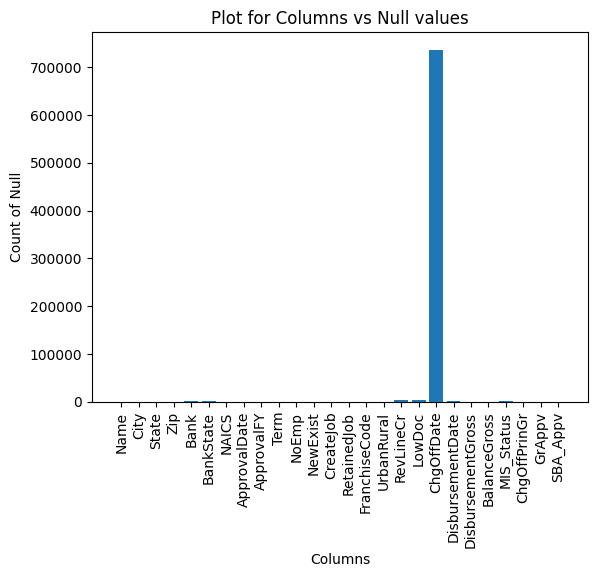

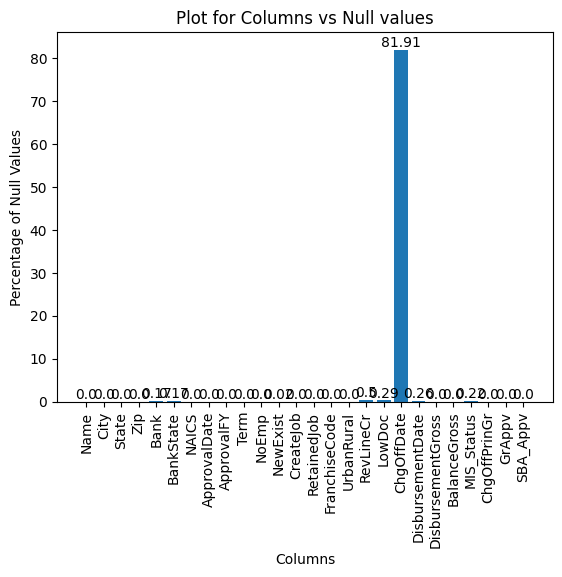

In [8]:
# Checking for any Nan value in each columns
cols = df_train.columns
dic_nan_values = {}
dic_prec_values = {}
for col in cols:
    # print(f"Nan -> {col} : {df_train[col].isnull().sum()}")
    dic_nan_values[col] = df_train[col].isnull().sum()
    dic_prec_values[col] = (df_train[col].isnull().sum() / df_train.shape[0]) * 100

bars = plt.bar(dic_nan_values.keys(), dic_nan_values.values())
plt.xlabel("Columns")
plt.ylabel("Count of Null")
plt.title("Plot for Columns vs Null values")
plt.xticks(rotation=90)
plt.show()

bars = plt.bar(dic_prec_values.keys(), dic_prec_values.values())
plt.xlabel("Columns")
plt.ylabel("Percentage of Null Values")
plt.title("Plot for Columns vs Null values")
plt.xticks(rotation=90)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')


plt.show()

In [9]:
target = "GrAppv"

currency_cols = [
    "DisbursementGross", "BalanceGross", "ChgOffPrinGr", "GrAppv", "SBA_Appv"
]

date_cols = ["ApprovalDate", "DisbursementDate", "ChgOffDate"]

numeric_features = [
    "Term", "NoEmp", "CreateJob", "RetainedJob", "ApprovalFY",
    "approval_year", "approval_month", "City_freq", "Zip_freq", "Bank_freq"
]

categorical_features = [
    "State", "BankState", "NewExist", "UrbanRural", "RevLineCr", "LowDoc",
    "NAICS_sector", "is_franchise"
]

high_cardinality_features = ["City", "Zip", "Bank"]

leakage_features = [
    "SBA_Appv", "DisbursementGross", "BalanceGross", "MIS_Status",
    "ChgOffDate", "ChgOffPrinGr"
]

id_or_raw_features = [
    "Name", "ApprovalDate", "DisbursementDate", "NAICS", "FranchiseCode",
    "City", "Zip", "Bank"
]


Cleaning SBA values


In [10]:
# SBA stores dollar columns as strings with symbols and commas. We convert them to numbers.
def clean_money(series):
    return pd.to_numeric(
        series.astype(str).str.replace(r"[$,]", "", regex=True).str.strip(),
        errors="coerce"
    )

missing_tokens = ["", " ", "nan", "NaN", "None", "NULL", "N/A"]
df_train.replace(missing_tokens, np.nan, inplace=True)

for col in currency_cols:
    if col in df_train.columns:
        df_train[col] = clean_money(df_train[col])

for col in date_cols:
    if col in df_train.columns:
        df_train[col] = pd.to_datetime(df_train[col], errors="coerce")

for col in df_train.columns:
    missing_percent = round((df_train[col].isnull().sum() / df_train.shape[0]) * 100, 2)
    print(f"Nan -> {col} : {missing_percent}")


Nan -> Name : 0.0
Nan -> City : 0.0
Nan -> State : 0.0
Nan -> Zip : 0.0
Nan -> Bank : 0.17
Nan -> BankState : 0.17
Nan -> NAICS : 0.0
Nan -> ApprovalDate : 0.0
Nan -> ApprovalFY : 0.0
Nan -> Term : 0.0
Nan -> NoEmp : 0.0
Nan -> NewExist : 0.02
Nan -> CreateJob : 0.0
Nan -> RetainedJob : 0.0
Nan -> FranchiseCode : 0.0
Nan -> UrbanRural : 0.0
Nan -> RevLineCr : 0.5
Nan -> LowDoc : 0.29
Nan -> ChgOffDate : 81.91
Nan -> DisbursementDate : 0.26
Nan -> DisbursementGross : 0.0
Nan -> BalanceGross : 0.0
Nan -> MIS_Status : 0.22
Nan -> ChgOffPrinGr : 0.0
Nan -> GrAppv : 0.0
Nan -> SBA_Appv : 0.0


Since `GrAppv` is the target variable, rows without this value cannot be used for training. We will drop those rows and keep only positive approved loan amounts.


In [11]:
df_train.dropna(inplace=True, subset=[target])
df_train = df_train[df_train[target] > 0].copy()


Creating SBA-specific features


In [12]:
# ApprovalFY can contain values like "1976A", so we pull out the year.
if "ApprovalFY" in df_train.columns:
    df_train["ApprovalFY"] = pd.to_numeric(
        df_train["ApprovalFY"].astype(str).str.extract(r"(\d{4})")[0],
        errors="coerce"
    )

# NAICS is an industry code. The first two digits give a simple industry sector.
if "NAICS" in df_train.columns:
    naics_text = pd.to_numeric(df_train["NAICS"], errors="coerce").fillna(0).astype(int).astype(str).str.zfill(6)
    df_train["NAICS_sector"] = naics_text.str[:2]
    df_train["NAICS_sector"] = df_train["NAICS_sector"].replace("00", "Unknown")

# FranchiseCode values 0 and 1 mean no franchise in this dataset.
if "FranchiseCode" in df_train.columns:
    franchise_code = pd.to_numeric(df_train["FranchiseCode"], errors="coerce").fillna(0)
    df_train["is_franchise"] = np.where(franchise_code > 1, "Yes", "No")

# Clean the common SBA code columns into human-readable categories.
def clean_yes_no(series):
    cleaned = series.astype(str).str.strip().str.upper()
    cleaned = cleaned.replace({"0": "N", "1": "Y", "T": "Y"})
    return cleaned.where(cleaned.isin(["Y", "N"]), "Unknown")

if "RevLineCr" in df_train.columns:
    df_train["RevLineCr"] = clean_yes_no(df_train["RevLineCr"])

if "LowDoc" in df_train.columns:
    df_train["LowDoc"] = clean_yes_no(df_train["LowDoc"])

if "NewExist" in df_train.columns:
    new_exist = pd.to_numeric(df_train["NewExist"], errors="coerce")
    df_train["NewExist"] = new_exist.map({1: "Existing", 2: "New"}).fillna("Unknown")

if "UrbanRural" in df_train.columns:
    urban_rural = pd.to_numeric(df_train["UrbanRural"], errors="coerce")
    df_train["UrbanRural"] = urban_rural.map({0: "Unknown", 1: "Urban", 2: "Rural"}).fillna("Unknown")

# High-cardinality columns are converted to frequency features to keep the model input small.
for col in high_cardinality_features:
    if col in df_train.columns:
        cleaned = df_train[col].astype(str).str.strip().str.upper()
        cleaned = cleaned.mask(cleaned.isin(["", "NAN", "NONE", "NULL"]), "Unknown")
        frequencies = cleaned.value_counts(normalize=True)
        df_train[f"{col}_freq"] = cleaned.map(frequencies)

# Approval date is available at approval time, so it is safe to use as a time feature.
if "ApprovalDate" in df_train.columns:
    df_train["approval_year"] = df_train["ApprovalDate"].dt.year
    df_train["approval_month"] = df_train["ApprovalDate"].dt.month


Filling missing values


In [13]:
# Median is stable for numeric fields. Unknown keeps missing categories visible to the model.
for col in numeric_features:
    if col in df_train.columns:
        df_train[col] = pd.to_numeric(df_train[col], errors="coerce")
        fill_value = df_train[col].median()
        if pd.isna(fill_value):
            raise ValueError(f"{col} has no valid numeric values to impute.")
        df_train[col] = df_train[col].fillna(fill_value)

for col in categorical_features:
    if col in df_train.columns:
        df_train[col] = df_train[col].astype(str).str.strip()
        df_train[col] = df_train[col].replace({"": "Unknown", "nan": "Unknown", "NaN": "Unknown"})
        df_train[col] = df_train[col].fillna("Unknown")


In [14]:
for col in df_train.columns:
    missing_percent = round((df_train[col].isnull().sum() / df_train.shape[0]) * 100, 2)
    print(f"Nan -> {col} : {missing_percent}")


Nan -> Name : 0.0
Nan -> City : 0.0
Nan -> State : 0.0
Nan -> Zip : 0.0
Nan -> Bank : 0.17
Nan -> BankState : 0.0
Nan -> NAICS : 0.0
Nan -> ApprovalDate : 0.0
Nan -> ApprovalFY : 0.0
Nan -> Term : 0.0
Nan -> NoEmp : 0.0
Nan -> NewExist : 0.0
Nan -> CreateJob : 0.0
Nan -> RetainedJob : 0.0
Nan -> FranchiseCode : 0.0
Nan -> UrbanRural : 0.0
Nan -> RevLineCr : 0.0
Nan -> LowDoc : 0.0
Nan -> ChgOffDate : 81.91
Nan -> DisbursementDate : 0.26
Nan -> DisbursementGross : 0.0
Nan -> BalanceGross : 0.0


Nan -> MIS_Status : 0.22
Nan -> ChgOffPrinGr : 0.0
Nan -> GrAppv : 0.0
Nan -> SBA_Appv : 0.0
Nan -> NAICS_sector : 0.0
Nan -> is_franchise : 0.0
Nan -> City_freq : 0.0
Nan -> Zip_freq : 0.0
Nan -> Bank_freq : 0.0
Nan -> approval_year : 0.0
Nan -> approval_month : 0.0


Outliers


In [15]:
# Large SBA loans are valid, so we do not remove target outliers.
# We only cap extreme business-size inputs to reduce noisy spikes.
for col in ["NoEmp", "CreateJob", "RetainedJob"]:
    if col in df_train.columns:
        lower = df_train[col].quantile(0.01)
        upper = df_train[col].quantile(0.99)
        df_train[col] = df_train[col].clip(lower=lower, upper=upper)
        print(f"Capped {col} between {round(lower, 2)} and {round(upper, 2)}")


Capped NoEmp between 1.0 and 95.0
Capped CreateJob between 0.0 and 30.0
Capped RetainedJob between 0.0 and 55.0


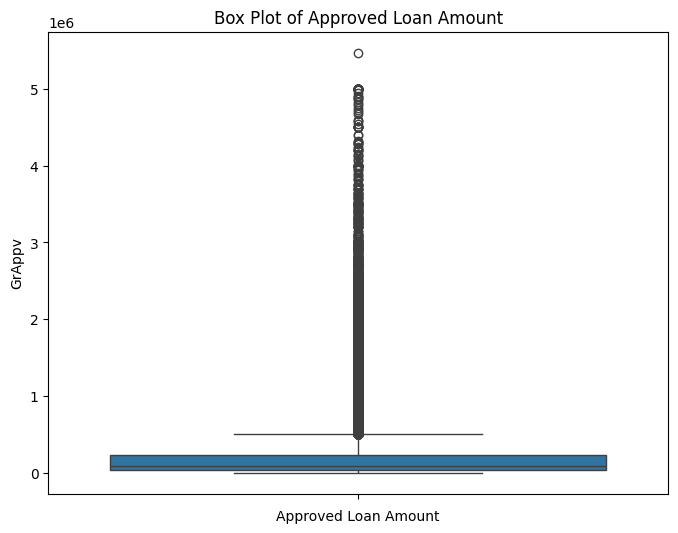

In [16]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_train[target])
plt.title("Box Plot of Approved Loan Amount")
plt.xlabel("Approved Loan Amount")
plt.show()


In [17]:
df_train.head(5)


,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,Term,...,ChgOffPrinGr,GrAppv,SBA_Appv,NAICS_sector,is_franchise,City_freq,Zip_freq,Bank_freq,approval_year,approval_month
LoanNr_ChkDgt,,,,,,,,,,,,,,,,,,,,,
1000014003,ABC HOBBYCRAFT,EVANSVILLE,IN,47711,FIFTH THIRD BANK,OH,451120,1997-02-28,1997,84,...,0.0,60000.0,48000.0,45,No,0.000381,0.000065,0.005801,1997,2
1000024006,LANDMARK BAR & GRILLE (THE),NEW PARIS,IN,46526,1ST SOURCE BANK,IN,722410,1997-02-28,1997,60,...,0.0,40000.0,32000.0,72,No,0.000022,0.000061,0.000890,1997,2
1000034009,"WHITLOCK DDS, TODD M.",BLOOMINGTON,IN,47401,GRANT COUNTY STATE BANK,IN,621210,1997-02-28,1997,180,...,0.0,287000.0,215250.0,62,No,0.001129,0.000102,0.000007,1997,2
1000044001,"BIG BUCKS PAWN & JEWELRY, LLC",BROKEN ARROW,OK,74012,1ST NATL BK & TR CO OF BROKEN,OK,0,1997-02-28,1997,60,...,0.0,35000.0,28000.0,Unknown,No,0.000389,0.000262,0.000060,1997,2
1000054004,"ANASTASIA CONFECTIONS, INC.",ORLANDO,FL,32801,FLORIDA BUS. DEVEL CORP,FL,0,1997-02-28,1997,240,...,0.0,229000.0,229000.0,Unknown,No,0.002505,0.000105,0.002007,1997,2


In [18]:
# This file keeps the cleaned SBA data before final model encoding.
df_train.to_csv(DATA_DIR / "sba_cleaned.csv")


### 2. Exploratory Data Analysis

EDA helps us understand the SBA loan data before modeling. Since this dataset is about business loans, the focus is now approved loan amount, business size, location, industry, and loan program fields.


### 2.1 Univariate Analysis

Univariate analysis looks at one feature at a time. This helps us understand the range, shape, and most common values for important columns.


Functions used for EDA of each feature:


In [19]:
def count_value(df, feature, top_n=10):
    counts = df[feature].value_counts(dropna=False).head(top_n)
    percentages = (counts / len(df) * 100).round(2)
    return pd.DataFrame({"Count": counts, "Percentage": percentages})


def get_numeric_summary(df, feature):
    return df[feature].describe().to_frame(name=feature)


def create_bar_plot(df, feature, top_n=10):
    value_counts = df[feature].value_counts(dropna=False).head(top_n)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=value_counts.index.astype(str), y=value_counts.values)
    plt.title(f"Top {top_n} values for {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.show()


def create_hist_plot(df, feature, bins=50, log_transform=False):
    data = df[feature].dropna()
    title = f"Distribution of {feature}"

    if log_transform:
        data = np.log1p(data)
        title = f"Log Distribution of {feature}"

    plt.figure(figsize=(10, 5))
    sns.histplot(data, bins=bins, kde=True)
    plt.title(title)
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.show()


def create_box_plot(df, feature, log_scale=False):
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=df[feature])
    if log_scale:
        plt.yscale("log")
    plt.title(f"Box Plot of {feature}")
    plt.ylabel(feature)
    plt.show()


#### Approved Loan Amount


In [20]:
get_numeric_summary(df_train, target)


,GrAppv
count,8.991640e+05
mean,1.926870e+05
std,2.832634e+05
min,2.000000e+02
25%,3.500000e+04
50%,9.000000e+04
75%,2.250000e+05
max,5.472000e+06


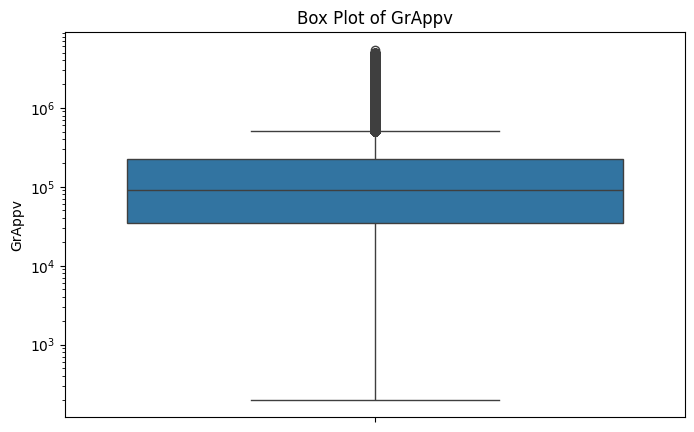

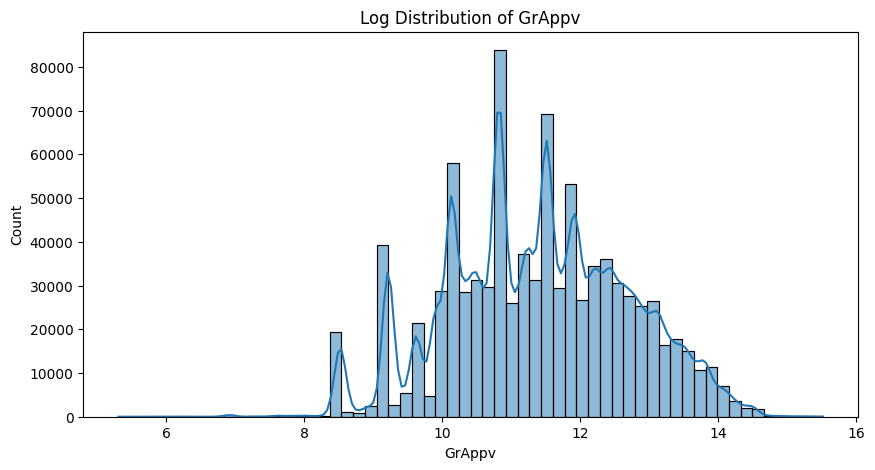

In [21]:
create_box_plot(df_train, target, log_scale=True)
create_hist_plot(df_train, target, bins=60, log_transform=True)


Interpretation:
1. `GrAppv` is strongly right-skewed, with many smaller loans and fewer very large loans.
2. This is normal for money lending data. It is a good reason to use MAE/RMSE and possibly try a log target later.


#### Loan Term


In [22]:
get_numeric_summary(df_train, "Term")


,Term
count,899164.000000
mean,110.773078
std,78.857305
min,0.000000
25%,60.000000
50%,84.000000
75%,120.000000
max,569.000000


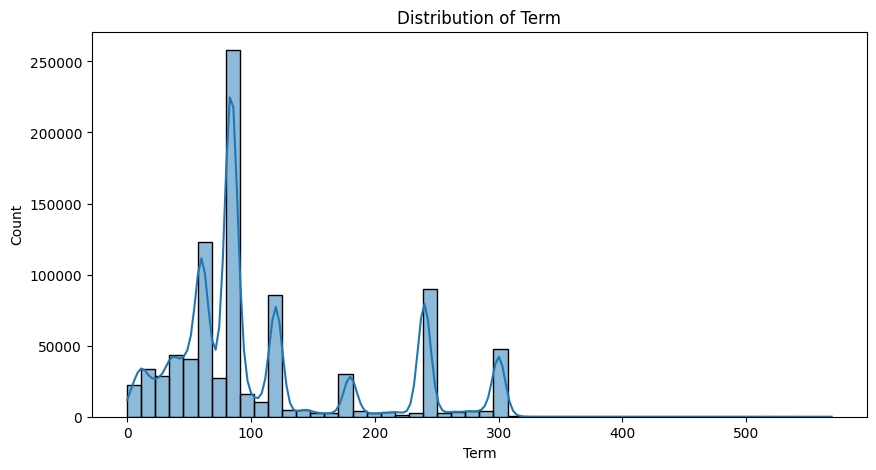

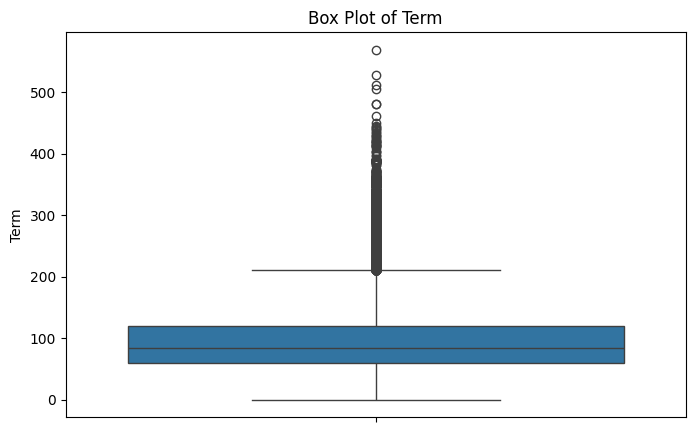

In [23]:
create_hist_plot(df_train, "Term", bins=50)
create_box_plot(df_train, "Term")


Interpretation:
1. `Term` is measured in months.
2. This is one of the most important lending fields because larger loans often have longer repayment periods.


#### Business Size and Jobs


In [24]:
job_cols = ["NoEmp", "CreateJob", "RetainedJob"]
df_train[job_cols].describe()


,NoEmp,CreateJob,RetainedJob
count,899164.000000,899164.000000,899164.000000
mean,9.780418,1.771807,3.985966
std,15.192780,4.722601,8.624213
min,1.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000
50%,4.000000,0.000000,1.000000
75%,10.000000,1.000000,4.000000
max,95.000000,30.000000,55.000000


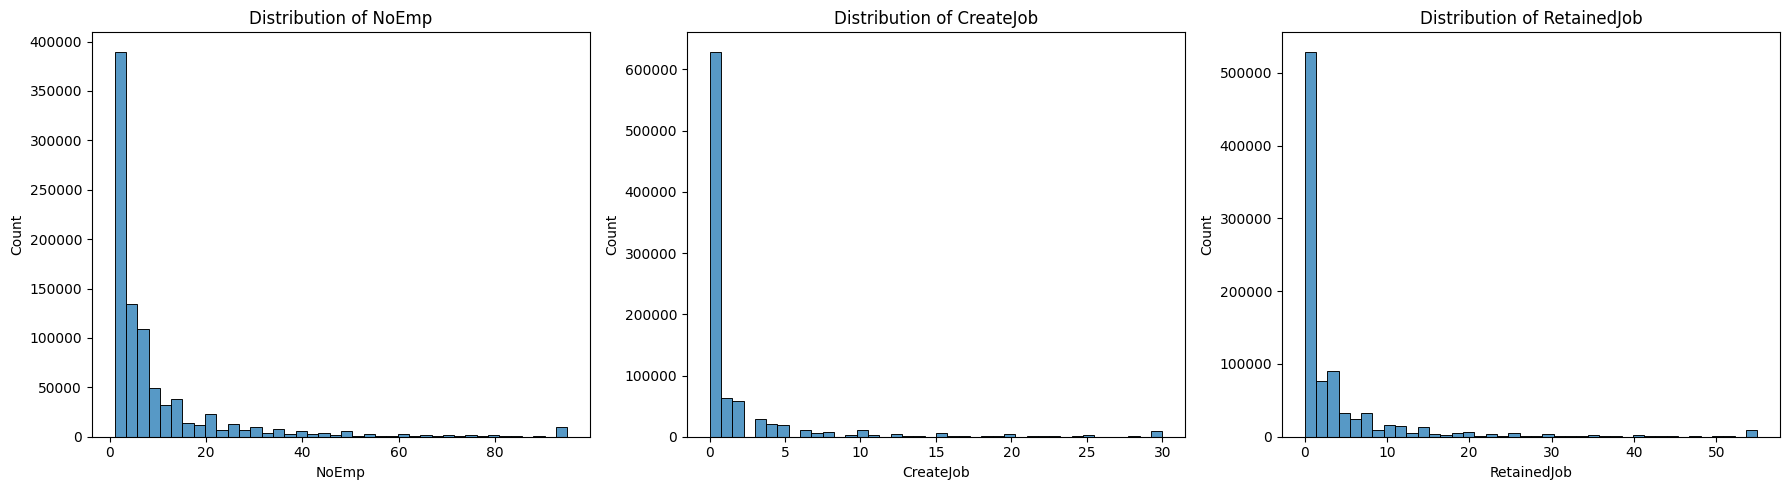

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, job_cols):
    sns.histplot(df_train[col], bins=40, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()


Interpretation:
1. Many SBA loans are for small businesses with few employees.
2. `CreateJob` and `RetainedJob` have many valid zeros. A zero here usually means no jobs were recorded as created or retained, not missing data.


#### Business Type and Program Flags



NewExist


,Count,Percentage
NewExist,,
Existing,644869,71.72
New,253125,28.15
Unknown,1170,0.13


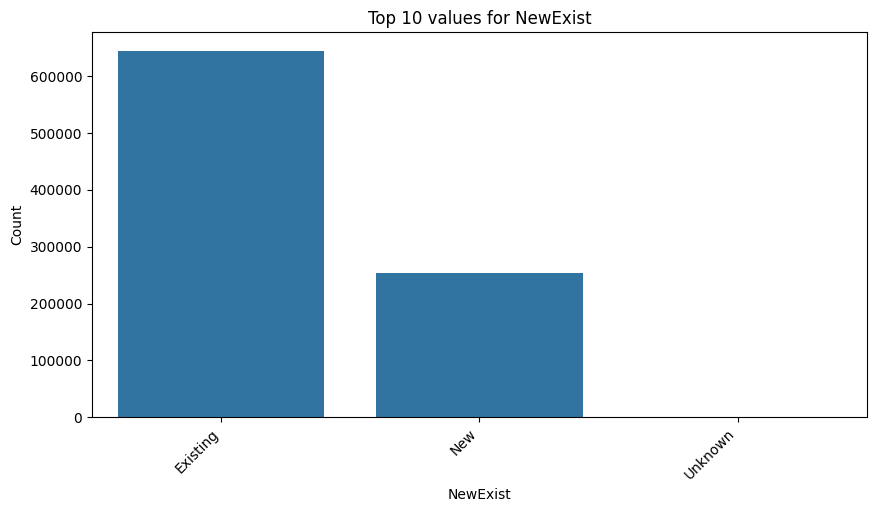


UrbanRural


,Count,Percentage
UrbanRural,,
Urban,470654,52.34
Unknown,323167,35.94
Rural,105343,11.72


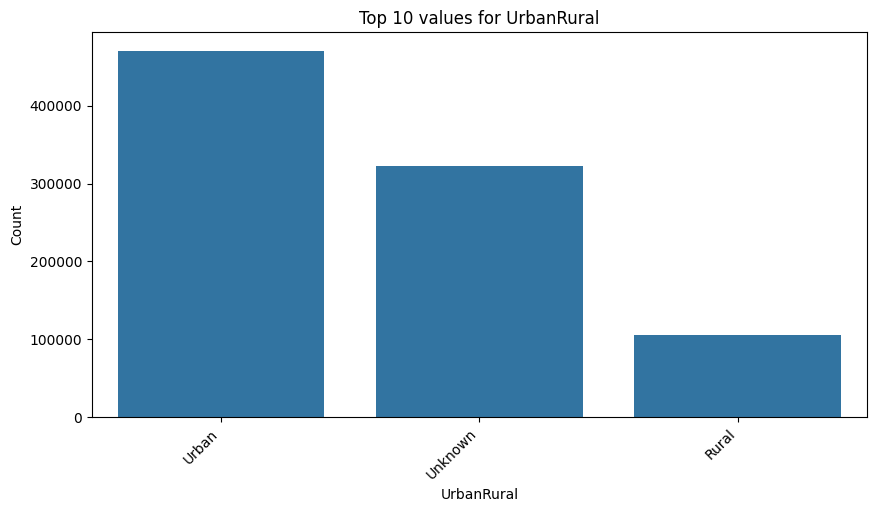


RevLineCr


,Count,Percentage
RevLineCr,,
N,677890,75.39
Y,216704,24.10
Unknown,4570,0.51


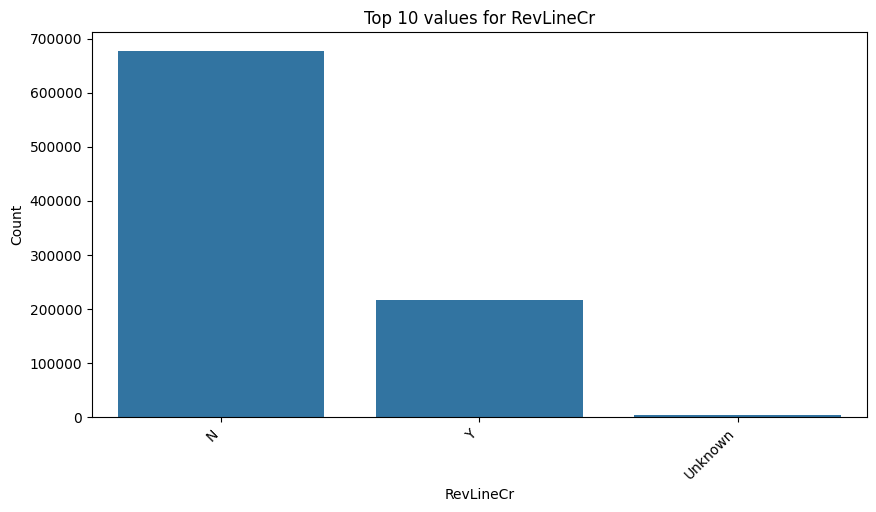


LowDoc


,Count,Percentage
LowDoc,,
N,784313,87.23
Y,110336,12.27
Unknown,4515,0.50


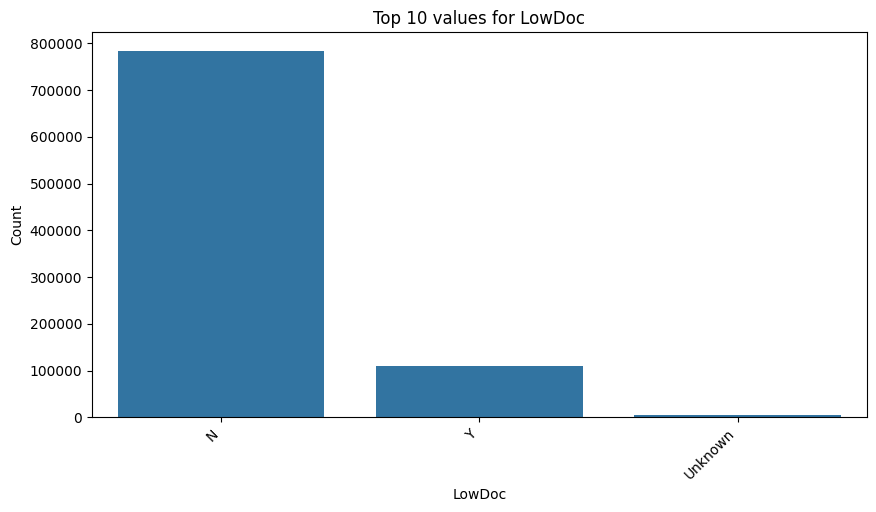


is_franchise


,Count,Percentage
is_franchise,,
No,847389,94.24
Yes,51775,5.76


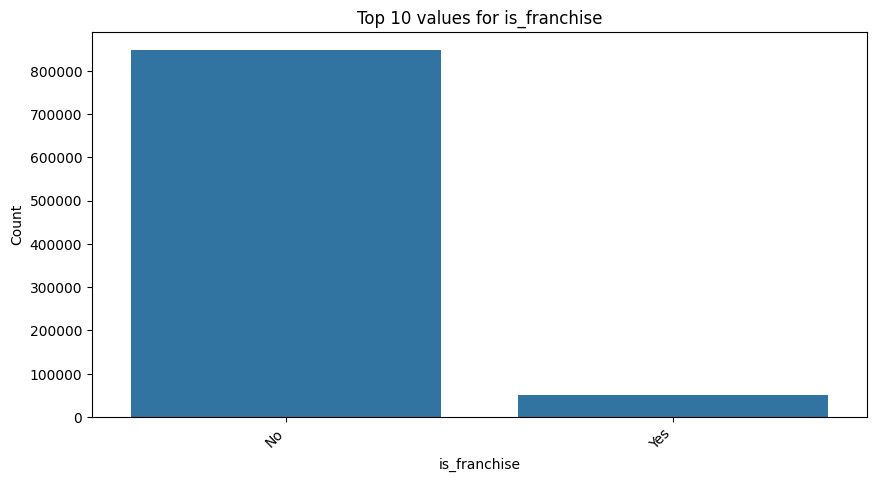

In [26]:
program_cols = ["NewExist", "UrbanRural", "RevLineCr", "LowDoc", "is_franchise"]

for col in program_cols:
    print()
    print(col)
    display(count_value(df_train, col))
    create_bar_plot(df_train, col)


Interpretation:
1. These fields describe whether the borrower is a new business, whether the location is urban/rural, and whether the loan used specific SBA programs.
2. They are useful categorical predictors for approved loan amount.


#### State and Industry


Top States


,Count,Percentage
State,,
CA,130619,14.53
TX,70458,7.84
NY,57693,6.42
FL,41212,4.58
PA,35170,3.91
OH,32622,3.63
IL,29669,3.30
MA,25272,2.81
MN,24373,2.71


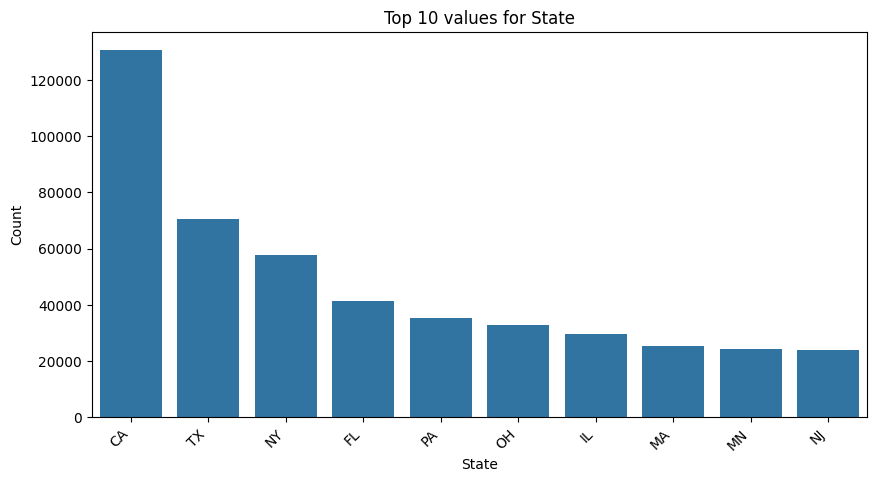

Top NAICS Sectors


,Count,Percentage
NAICS_sector,,
Unknown,201948,22.46
44,84737,9.42
81,72618,8.08
54,68170,7.58
72,67600,7.52
23,66646,7.41
62,55366,6.16
42,48743,5.42
45,42514,4.73


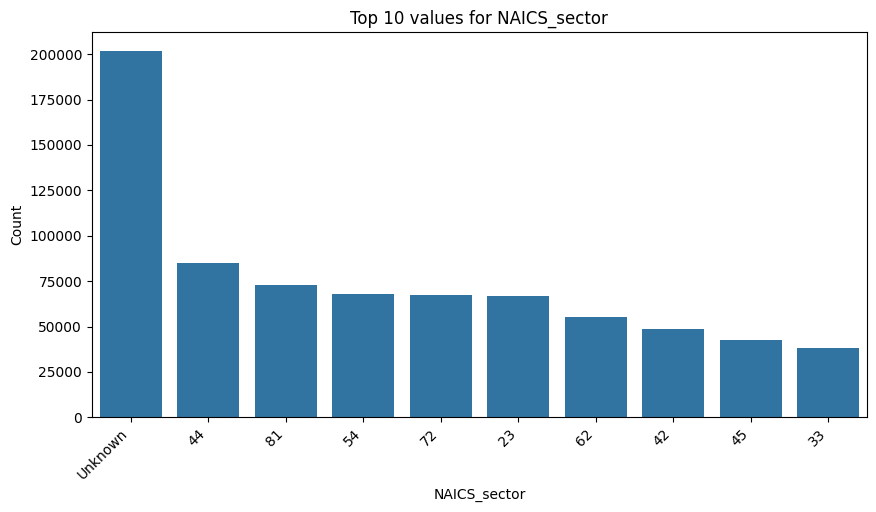

In [27]:
print("Top States")
display(count_value(df_train, "State", top_n=10))
create_bar_plot(df_train, "State", top_n=10)

print("Top NAICS Sectors")
display(count_value(df_train, "NAICS_sector", top_n=10))
create_bar_plot(df_train, "NAICS_sector", top_n=10)


Interpretation:
1. `State` captures where the business is located.
2. `NAICS_sector` captures broad industry groups. These two features help the model learn differences across geography and industry.


### 2.2 Multivariate Analysis

Multivariate analysis looks at how multiple features move together. This is useful for checking which features are related to `GrAppv`.


#### Correlation Analysis


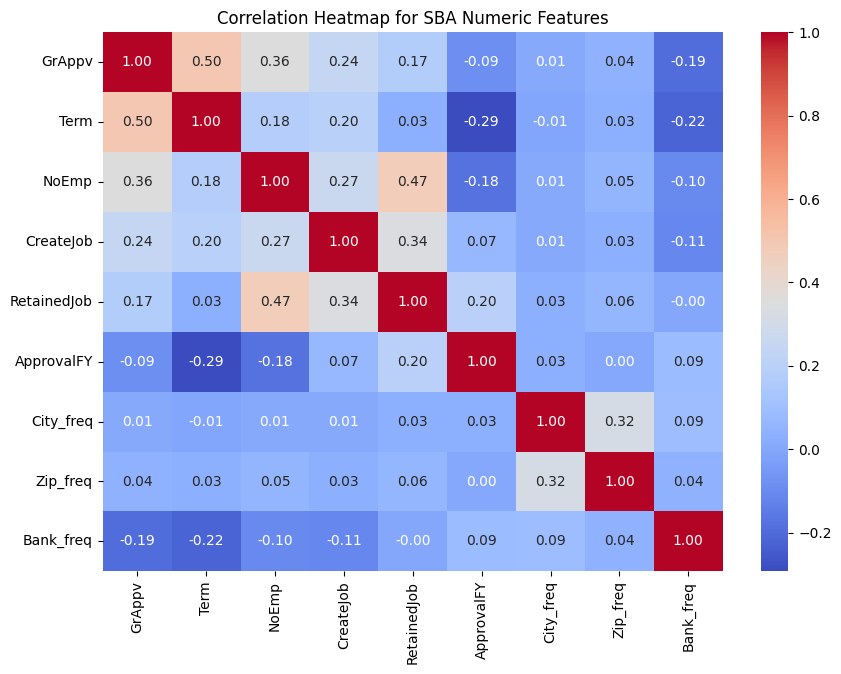

In [28]:
correlation_cols = [
    target, "Term", "NoEmp", "CreateJob", "RetainedJob", "ApprovalFY",
    "City_freq", "Zip_freq", "Bank_freq"
]
correlation_cols = [col for col in correlation_cols if col in df_train.columns]

plt.figure(figsize=(10, 7))
sns.heatmap(df_train[correlation_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap for SBA Numeric Features")
plt.show()


From the heatmap, we can see which numeric features have the strongest linear relationship with approved loan amount. This does not prove causation, but it is a useful first check.


#### Loan Term vs Approved Loan Amount


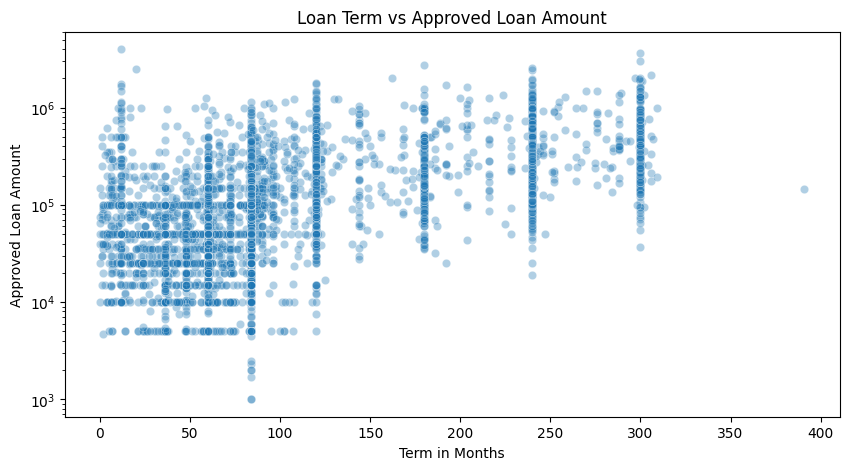

In [29]:
eda_sample = df_train.sample(n=min(5000, len(df_train)), random_state=42)

plt.figure(figsize=(10, 5))
sns.scatterplot(data=eda_sample, x="Term", y=target, alpha=0.35)
plt.yscale("log")
plt.title("Loan Term vs Approved Loan Amount")
plt.xlabel("Term in Months")
plt.ylabel("Approved Loan Amount")
plt.show()


Interpretation:
1. Longer loan terms are often linked with larger approved amounts.
2. The relationship is not perfect, so other business and loan features are still needed.


#### Employees vs Approved Loan Amount


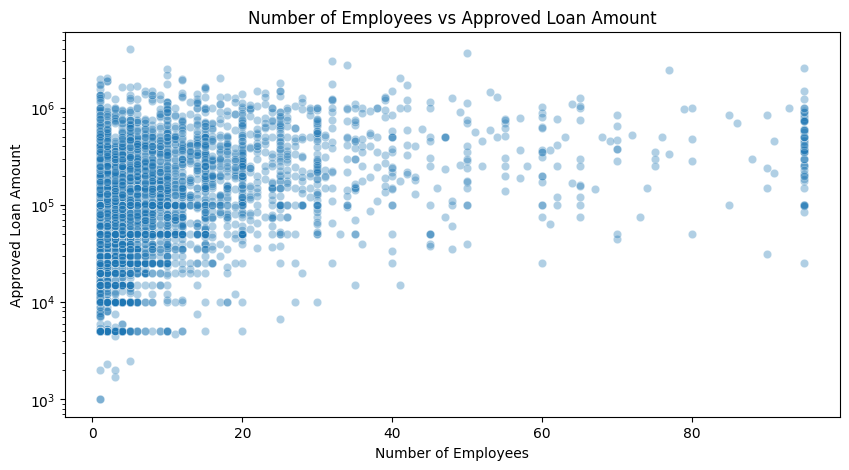

In [30]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=eda_sample, x="NoEmp", y=target, alpha=0.35)
plt.yscale("log")
plt.title("Number of Employees vs Approved Loan Amount")
plt.xlabel("Number of Employees")
plt.ylabel("Approved Loan Amount")
plt.show()


Interpretation:
1. Businesses with more employees can receive larger loans, but the relationship is noisy.
2. This means employee count should help the model, but it will not be enough by itself.


#### Average Approved Amount by State and Industry


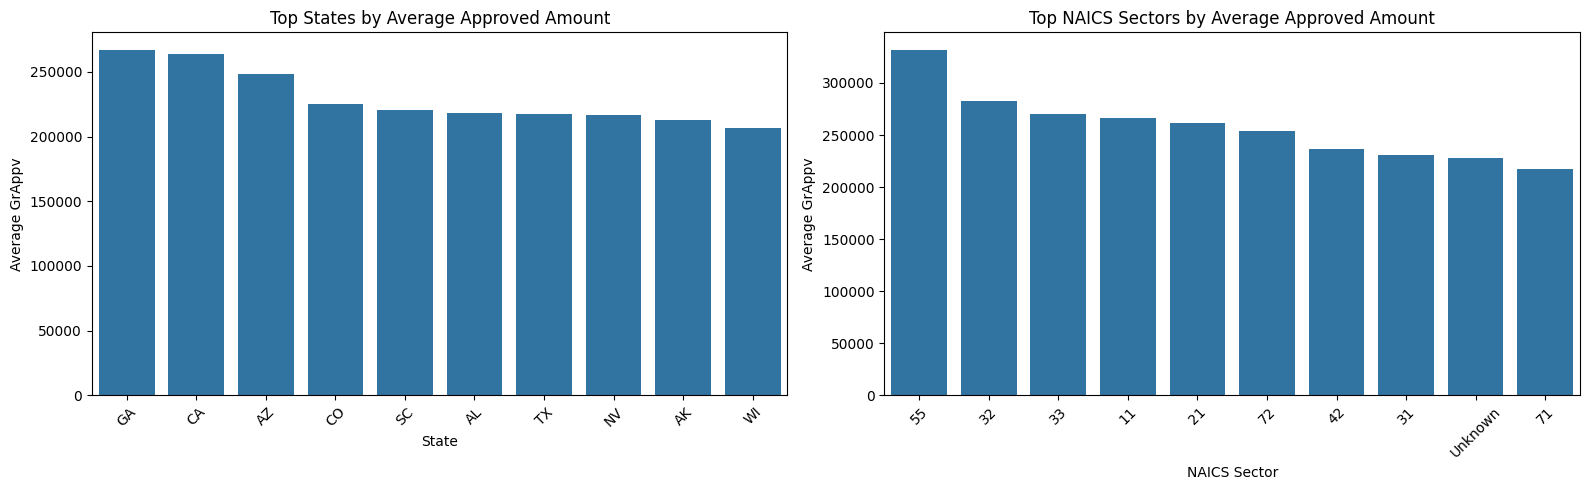

In [31]:
state_avg = df_train.groupby("State")[target].mean().sort_values(ascending=False).head(10)
sector_avg = df_train.groupby("NAICS_sector")[target].mean().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=state_avg.index.astype(str), y=state_avg.values, ax=axes[0])
axes[0].set_title("Top States by Average Approved Amount")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Average GrAppv")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(x=sector_avg.index.astype(str), y=sector_avg.values, ax=axes[1])
axes[1].set_title("Top NAICS Sectors by Average Approved Amount")
axes[1].set_xlabel("NAICS Sector")
axes[1].set_ylabel("Average GrAppv")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


Interpretation:
1. Some states and industries have higher average approved loan amounts than others.
2. This supports keeping both geography and industry features in preprocessing.


#### Approved Loan Amount by Program Flags


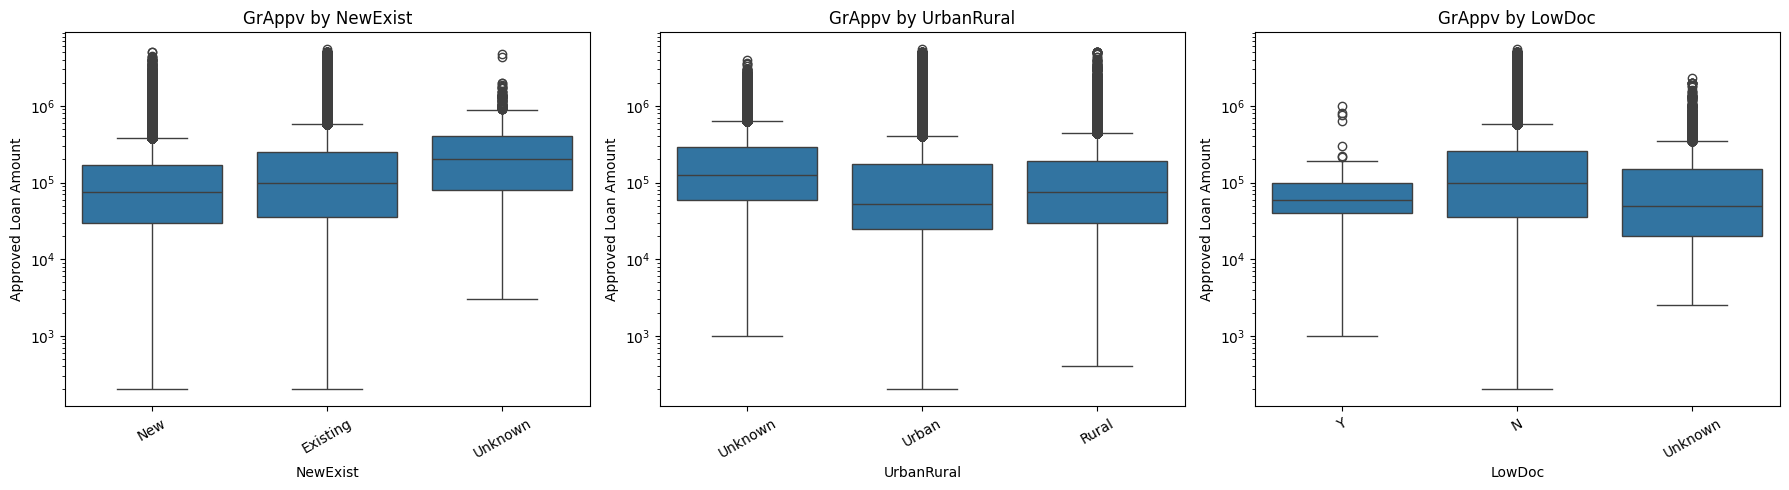

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ["NewExist", "UrbanRural", "LowDoc"]):
    sns.boxplot(data=df_train, x=col, y=target, ax=ax)
    ax.set_yscale("log")
    ax.set_title(f"{target} by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Approved Loan Amount")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


Interpretation:
1. Program flags show whether loan amount changes across business and SBA loan categories.
2. These patterns are useful for tree-based models and regularized linear models.


### Feature Selection and Encoding

In this step, we keep only the SBA fields that would be available around loan approval time. This keeps the model honest by avoiding post-loan leakage such as charge-off status, charge-off amount, and the SBA guaranteed amount.


In [33]:
# These features are allowed for predicting GrAppv.
# Leakage columns like SBA_Appv, DisbursementGross, MIS_Status, and ChgOffPrinGr are not included.
selected_numeric_features = [
    "Term", "NoEmp", "CreateJob", "RetainedJob", "ApprovalFY",
    "approval_year", "approval_month", "City_freq", "Zip_freq", "Bank_freq"
]

selected_categorical_features = [
    "State", "BankState", "NewExist", "UrbanRural", "RevLineCr", "LowDoc",
    "NAICS_sector", "is_franchise"
]

selected_numeric_features = [col for col in selected_numeric_features if col in df_train.columns]
selected_categorical_features = [col for col in selected_categorical_features if col in df_train.columns]
selected_features = selected_numeric_features + selected_categorical_features

df_model = df_train[selected_features + [target]].copy()

feature_summary = pd.DataFrame({
    "Feature": selected_features,
    "Type": ["Numeric"] * len(selected_numeric_features) + ["Categorical"] * len(selected_categorical_features)
})

feature_summary


,Feature,Type
0,Term,Numeric
1,NoEmp,Numeric
2,CreateJob,Numeric
3,RetainedJob,Numeric
4,ApprovalFY,Numeric
5,approval_year,Numeric
6,approval_month,Numeric
7,City_freq,Numeric
8,Zip_freq,Numeric
9,Bank_freq,Numeric


In [34]:
print(f"Rows selected for modeling: {df_model.shape[0]}")
print(f"Selected input features: {len(selected_features)}")
print(f"Numeric features: {len(selected_numeric_features)}")
print(f"Categorical features: {len(selected_categorical_features)}")


Rows selected for modeling: 899164
Selected input features: 18
Numeric features: 10
Categorical features: 8


In [35]:
df_model.head(5)


,Term,NoEmp,CreateJob,RetainedJob,ApprovalFY,approval_year,approval_month,City_freq,Zip_freq,Bank_freq,State,BankState,NewExist,UrbanRural,RevLineCr,LowDoc,NAICS_sector,is_franchise,GrAppv
LoanNr_ChkDgt,,,,,,,,,,,,,,,,,,,
1000014003,84,4,0,0,1997,1997,2,0.000381,0.000065,0.005801,IN,OH,New,Unknown,N,Y,45,No,60000.0
1000024006,60,2,0,0,1997,1997,2,0.000022,0.000061,0.000890,IN,IN,New,Unknown,N,Y,72,No,40000.0
1000034009,180,7,0,0,1997,1997,2,0.001129,0.000102,0.000007,IN,IN,Existing,Unknown,N,N,62,No,287000.0
1000044001,60,2,0,0,1997,1997,2,0.000389,0.000262,0.000060,OK,OK,Existing,Unknown,N,Y,Unknown,No,35000.0
1000054004,240,14,7,7,1997,1997,2,0.002505,0.000105,0.002007,FL,FL,Existing,Unknown,N,N,Unknown,No,229000.0


In [36]:
# Job and employee counts are right-skewed, so we compress them with log1p.
# log1p keeps real zero values valid and makes large values less extreme.
skewed_count_features = ["NoEmp", "CreateJob", "RetainedJob"]

for col in skewed_count_features:
    if col in df_model.columns:
        df_model[col] = np.log1p(df_model[col])


In [37]:
from scipy.stats import skew

def compute_skewness(df):
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    skew_values = {col: skew(df[col].dropna()) for col in numerical_cols}
    skew_df = pd.DataFrame(list(skew_values.items()), columns=["Column", "Skewness"])
    skew_df.sort_values(by="Skewness", key=lambda x: x.abs(), ascending=False, inplace=True)
    return skew_df

skew_df = compute_skewness(df_model[selected_numeric_features + [target]])
skew_df


,Column,Skewness
10,GrAppv,3.520784
7,City_freq,3.138670
8,Zip_freq,2.248024
2,CreateJob,1.784593
9,Bank_freq,1.205618
0,Term,1.120924
3,RetainedJob,1.006199
1,NoEmp,0.769903
4,ApprovalFY,-0.585378
5,approval_year,-0.130840


In [38]:
# One-hot encoding creates many 0 values by design.
# A dummy column is 1 only when the row belongs to that category, and 0 otherwise.
df_processed = pd.get_dummies(
    df_model,
    columns=selected_categorical_features,
    drop_first=False,
    dtype=int
)

# Keep the target as the last column. This also helps older modeling cells that expect y at the end.
model_feature_cols = [col for col in df_processed.columns if col != target]
df_processed = df_processed[model_feature_cols + [target]]


In [39]:
print(f"Columns after encoding: {df_processed.shape[1]}")
print(f"Model input features after encoding: {len(model_feature_cols)}")
print(f"Dummy columns created: {len(model_feature_cols) - len(selected_numeric_features)}")


Columns after encoding: 159
Model input features after encoding: 158
Dummy columns created: 148


In [40]:
df_processed.head(5)


,Term,NoEmp,CreateJob,RetainedJob,ApprovalFY,approval_year,approval_month,City_freq,Zip_freq,Bank_freq,...,NAICS_sector_61,NAICS_sector_62,NAICS_sector_71,NAICS_sector_72,NAICS_sector_81,NAICS_sector_92,NAICS_sector_Unknown,is_franchise_No,is_franchise_Yes,GrAppv
LoanNr_ChkDgt,,,,,,,,,,,,,,,,,,,,,
1000014003,84,1.609438,0.000000,0.000000,1997,1997,2,0.000381,0.000065,0.005801,...,0,0,0,0,0,0,0,1,0,60000.0
1000024006,60,1.098612,0.000000,0.000000,1997,1997,2,0.000022,0.000061,0.000890,...,0,0,0,1,0,0,0,1,0,40000.0
1000034009,180,2.079442,0.000000,0.000000,1997,1997,2,0.001129,0.000102,0.000007,...,0,1,0,0,0,0,0,1,0,287000.0
1000044001,60,1.098612,0.000000,0.000000,1997,1997,2,0.000389,0.000262,0.000060,...,0,0,0,0,0,0,1,1,0,35000.0
1000054004,240,2.708050,2.079442,2.079442,1997,1997,2,0.002505,0.000105,0.002007,...,0,0,0,0,0,0,1,1,0,229000.0


In [41]:
# Keep a copy for later PCA or dimensionality-reduction experiments.
df_pca = df_processed.copy()


In [42]:
# Final safety check: every feature should be numeric and complete before scaling and modeling.
# We do not fill remaining NaN values with 0 here because that can hide preprocessing mistakes.
feature_cols = [col for col in df_processed.columns if col != target]
df_processed[feature_cols] = df_processed[feature_cols].replace([np.inf, -np.inf], np.nan)

missing_after_encoding = df_processed[feature_cols].isnull().sum()
missing_after_encoding = missing_after_encoding[missing_after_encoding > 0]

if not missing_after_encoding.empty:
    print(missing_after_encoding.sort_values(ascending=False).head(20))
    raise ValueError("Missing values remain after feature selection and encoding.")

non_numeric_cols = df_processed[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()

if non_numeric_cols:
    raise ValueError(f"These columns still need encoding: {non_numeric_cols}")

print("Feature selection and encoding checks passed.")


Feature selection and encoding checks passed.


In [43]:
# Check how sparse the encoded data is.
# High zero percentages are expected for rare category dummy columns.
zero_percent = (df_processed[feature_cols] == 0).mean().sort_values(ascending=False).head(15) * 100
zero_percent.round(2).to_frame("Zero Percentage")


,Zero Percentage
BankState_AN,100.00
BankState_EN,100.00
BankState_VI,100.00
BankState_GU,100.00
State_Unknown,100.00
BankState_PR,99.98
NAICS_sector_92,99.97
NAICS_sector_55,99.97
NAICS_sector_22,99.93
NewExist_Unknown,99.87


In [44]:
df_processed.to_csv(DATA_DIR / "preprocessed.csv", index=False)
df_processed.head(5)


,Term,NoEmp,CreateJob,RetainedJob,ApprovalFY,approval_year,approval_month,City_freq,Zip_freq,Bank_freq,...,NAICS_sector_61,NAICS_sector_62,NAICS_sector_71,NAICS_sector_72,NAICS_sector_81,NAICS_sector_92,NAICS_sector_Unknown,is_franchise_No,is_franchise_Yes,GrAppv
LoanNr_ChkDgt,,,,,,,,,,,,,,,,,,,,,
1000014003,84,1.609438,0.000000,0.000000,1997,1997,2,0.000381,0.000065,0.005801,...,0,0,0,0,0,0,0,1,0,60000.0
1000024006,60,1.098612,0.000000,0.000000,1997,1997,2,0.000022,0.000061,0.000890,...,0,0,0,1,0,0,0,1,0,40000.0
1000034009,180,2.079442,0.000000,0.000000,1997,1997,2,0.001129,0.000102,0.000007,...,0,1,0,0,0,0,0,1,0,287000.0
1000044001,60,1.098612,0.000000,0.000000,1997,1997,2,0.000389,0.000262,0.000060,...,0,0,0,0,0,0,1,1,0,35000.0
1000054004,240,2.708050,2.079442,2.079442,1997,1997,2,0.002505,0.000105,0.002007,...,0,0,0,0,0,0,1,1,0,229000.0


In [45]:
#### Preprocessing #####

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

target = "GrAppv"

X = df_processed.drop(columns=[target])
y = df_processed[target].values.reshape(-1, 1)

scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

X_train_scaled = pd.DataFrame(
    scaler_X.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler_X.transform(X_val), columns=X_val.columns, index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler_X.transform(X_test), columns=X_test.columns, index=X_test.index
)

y_train_scaled = scaler_Y.fit_transform(y_train).ravel()
y_val_scaled = scaler_Y.transform(y_val).ravel()
y_test_scaled = scaler_Y.transform(y_test).ravel()

print(f"Training rows: {X_train_scaled.shape[0]}")
print(f"Validation rows: {X_val_scaled.shape[0]}")
print(f"Test rows: {X_test_scaled.shape[0]}")
print(f"Model features: {X_train_scaled.shape[1]}")


Training rows: 575464
Validation rows: 143867
Test rows: 179833
Model features: 158


In [46]:
X_train_scaled.head(5)


,Term,NoEmp,CreateJob,RetainedJob,ApprovalFY,approval_year,approval_month,City_freq,Zip_freq,Bank_freq,...,NAICS_sector_56,NAICS_sector_61,NAICS_sector_62,NAICS_sector_71,NAICS_sector_72,NAICS_sector_81,NAICS_sector_92,NAICS_sector_Unknown,is_franchise_No,is_franchise_Yes
LoanNr_ChkDgt,,,,,,,,,,,,,,,,,,,,,
2749964002,0.053837,0.764224,0.744713,1.577268,-0.363624,-0.323950,-1.630478,1.520408,0.582750,-0.395009,...,-0.194036,-0.085229,-0.255676,-0.128375,-0.285244,-0.296499,-0.016039,1.858416,0.246815,-0.246815
3509873009,0.878295,-0.780867,-0.562380,-0.829211,-2.055241,-1.991739,0.451205,-0.544964,-0.952058,-0.534370,...,-0.194036,-0.085229,-0.255676,-0.128375,-0.285244,-0.296499,-0.016039,1.858416,0.246815,-0.246815
6015073009,0.117256,-0.780867,-0.562380,-0.829211,-1.209433,-1.324623,1.045972,-0.413403,-0.601244,-0.766125,...,-0.194036,-0.085229,-0.255676,-0.128375,-0.285244,-0.296499,-0.016039,-0.538093,0.246815,-0.246815
4937335004,-0.339367,-0.050492,0.744713,0.201526,1.835477,1.677397,1.343355,-0.434799,-0.267972,0.918499,...,-0.194036,-0.085229,-0.255676,-0.128375,3.505776,-0.296499,-0.016039,-0.538093,0.246815,-0.246815
8624213008,-0.339367,-0.050492,-0.562380,-0.829211,-1.040271,-0.991065,0.451205,1.171248,0.723075,-0.651386,...,-0.194036,-0.085229,-0.255676,-0.128375,-0.285244,-0.296499,-0.016039,1.858416,0.246815,-0.246815


### 3. Model Building and Evaluation

The target is `GrAppv`, the approved SBA loan amount. Each model is numbered in the order it is trained. The final selection is based on the model comparison table and the diagnostic plots, not on assumptions about which algorithm should work best.


### 3.1 Evaluation Setup

All models are trained on the full training split so the comparison is fair. Evaluation is done on the full test set.


In [47]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_log_error
import time

model_results = []
fitted_models = {}
model_predictions = {}

PCA_COMPONENTS = min(25, X_train_scaled.shape[1])

# Every model now trains on the full training split.
X_train_full = X_train_scaled
y_train_full = y_train_scaled

y_test_actual = y_test.ravel()

print(f"Full training rows: {X_train_scaled.shape[0]}")
print(f"Rows used to train each model: {X_train_full.shape[0]}")
print(f"Full test rows used for evaluation: {X_test_scaled.shape[0]}")


Full training rows: 575464
Rows used to train each model: 575464
Full test rows used for evaluation: 179833


In [48]:
def inverse_target(y_scaled):
    y_scaled = np.asarray(y_scaled).reshape(-1, 1)
    return scaler_Y.inverse_transform(y_scaled).ravel()


def evaluate_predictions(model_name, y_true, y_pred, fit_seconds=None):
    y_pred = np.asarray(y_pred).ravel()
    y_pred_non_negative = np.clip(y_pred, 0, None)

    result = {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "RMSLE": root_mean_squared_log_error(y_true, y_pred_non_negative),
    }

    if fit_seconds is not None:
        result["Fit Seconds"] = round(fit_seconds, 2)

    model_results.append(result)
    model_predictions[model_name] = y_pred
    return pd.DataFrame([result])


def fit_and_evaluate(model_name, model, X_fit, y_fit, X_eval=X_test_scaled):
    start_time = time.time()
    model.fit(X_fit, y_fit)
    fit_seconds = time.time() - start_time

    y_pred_scaled = model.predict(X_eval)
    y_pred = inverse_target(y_pred_scaled)

    fitted_models[model_name] = model
    return evaluate_predictions(model_name, y_test_actual, y_pred, fit_seconds)


### 3.2 Model 1: Linear Regression

Linear Regression gives us a clear baseline for how much a straight-line model can learn from the SBA features.


In [49]:
linear_model = LinearRegression()
fit_and_evaluate(
    "Linear Regression",
    linear_model,
    X_train_scaled,
    y_train_scaled,
)


,Model,MAE,RMSE,R2,RMSLE,Fit Seconds
0,Linear Regression,131472.613972,221235.696735,0.387598,3.537119,3.7


### 3.3 Model 2: Gradient Boosting

Gradient Boosting builds trees sequentially, where each tree tries to fix the mistakes of the previous trees. We train it on the full training split for this comparison.


In [50]:
gbr_model = GradientBoostingRegressor(
    n_estimators=80,
    learning_rate=0.06,
    max_depth=3,
    subsample=0.8,
    random_state=42,
)

fit_and_evaluate(
    "Gradient Boosting",
    gbr_model,
    X_train_full,
    y_train_full,
)


,Model,MAE,RMSE,R2,RMSLE,Fit Seconds
0,Gradient Boosting,112701.731813,206369.938473,0.467133,0.961412,134.48


### 3.4 Model 3: Random Forest

Random Forest averages many decision trees. It handles non-linear relationships well, but it can be expensive on a dataset this large.


In [51]:
random_forest_model = RandomForestRegressor(
    n_estimators=40,
    max_depth=16,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
)

fit_and_evaluate(
    "Random Forest",
    random_forest_model,
    X_train_full,
    y_train_full,
)


,Model,MAE,RMSE,R2,RMSLE,Fit Seconds
0,Random Forest,99895.005725,190297.985568,0.5469,0.797063,39.02


### 3.5 Model 4: PCA + Linear Regression

PCA reduces the encoded feature space into fewer components. This is not usually the strongest option for tree-friendly tabular data, but it updates the original PCA experiment for the SBA dataset.


In [52]:
pca = PCA(n_components=PCA_COMPONENTS, svd_solver="randomized", random_state=42)

start_time = time.time()
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
pca_model = LinearRegression()
pca_model.fit(X_train_pca, y_train_scaled)
fit_seconds = time.time() - start_time

y_pred_pca = inverse_target(pca_model.predict(X_test_pca))
fitted_models["PCA + Linear Regression"] = pca_model
model_predictions["PCA + Linear Regression"] = y_pred_pca
evaluate_predictions("PCA + Linear Regression", y_test_actual, y_pred_pca, fit_seconds)


,Model,MAE,RMSE,R2,RMSLE,Fit Seconds
0,PCA + Linear Regression,147484.716759,244161.230417,0.254102,3.283302,5.44


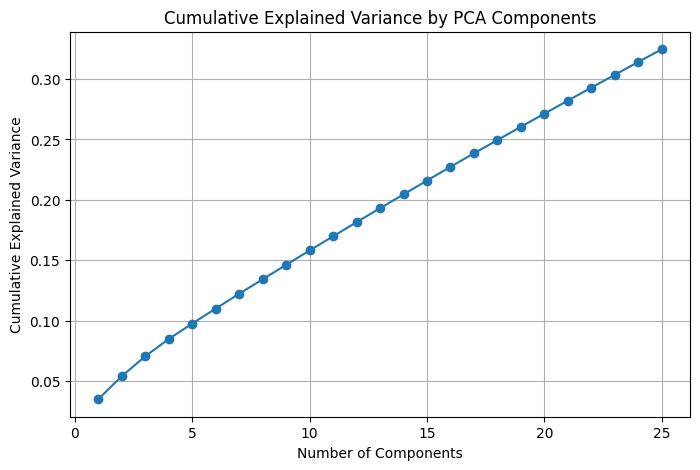

In [53]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()


### 3.6 Model 5: Neural Network

The original project used a Keras regression network. Here we keep a compact network architecture, but it is trained on the full training split.


In [54]:
try:
    import os
    os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
    from tensorflow.keras.callbacks import EarlyStopping

    tf.random.set_seed(42)

    neural_model = Sequential([
        Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),
        BatchNormalization(),
        Dropout(0.2),
        Dense(64, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1),
    ])

    neural_model.compile(
        optimizer="adam",
        loss="mean_squared_error",
        metrics=["mean_absolute_error"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
    )

    start_time = time.time()
    history = neural_model.fit(
        X_train_full,
        y_train_full,
        validation_data=(X_val_scaled, y_val_scaled),
        epochs=8,
        batch_size=2048,
        verbose=0,
        callbacks=[early_stop],
    )
    fit_seconds = time.time() - start_time

    y_pred_nn = inverse_target(neural_model.predict(X_test_scaled, verbose=0).ravel())
    fitted_models["Neural Network"] = neural_model
    model_predictions["Neural Network"] = y_pred_nn
    display(evaluate_predictions("Neural Network", y_test_actual, y_pred_nn, fit_seconds))
except ImportError:
    print("TensorFlow is not installed in this environment.")


E0000 00:00:1786132373.319531   61044 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


,Model,MAE,RMSE,R2,RMSLE,Fit Seconds
0,Neural Network,101811.424193,195869.401248,0.51998,0.888988,57.58


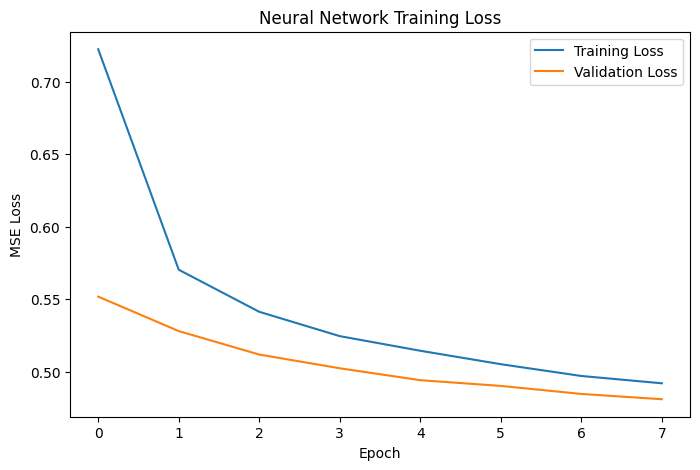

In [55]:
if "history" in globals():
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title("Neural Network Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.show()


### 3.7 Model 6: Ridge Regression

Ridge is a regularized linear model. It is usually a better linear baseline than plain Linear Regression when we have many encoded categorical features.


In [56]:
ridge_model = Ridge(alpha=10.0, random_state=42)
fit_and_evaluate(
    "Ridge Regression",
    ridge_model,
    X_train_scaled,
    y_train_scaled,
)


,Model,MAE,RMSE,R2,RMSLE,Fit Seconds
0,Ridge Regression,131472.114249,221235.684977,0.387598,3.537041,1.07


### 3.8 Model 7: HistGradientBoosting

HistGradientBoosting is a faster sklearn boosting model for larger tabular datasets. It is a good replacement for expensive grid-searched Gradient Boosting.


In [57]:
hist_gb_model = HistGradientBoostingRegressor(
    max_iter=180,
    learning_rate=0.06,
    max_leaf_nodes=31,
    l2_regularization=0.1,
    random_state=42,
)

fit_and_evaluate(
    "HistGradientBoosting",
    hist_gb_model,
    X_train_full,
    y_train_full,
)


,Model,MAE,RMSE,R2,RMSLE,Fit Seconds
0,HistGradientBoosting,102005.523941,190274.888749,0.54701,0.867423,17.16


### 3.9 Model 8: LightGBM

LightGBM is a strong gradient boosting library for tabular data. It is usually fast and accurate on large datasets like SBA loans.


In [58]:
try:
    from lightgbm import LGBMRegressor

    lightgbm_model = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )

    display(fit_and_evaluate(
        "LightGBM",
        lightgbm_model,
        X_train_full,
        y_train_full,
    ))
except ImportError:
    print("LightGBM is not installed in this environment.")


,Model,MAE,RMSE,R2,RMSLE,Fit Seconds
0,LightGBM,101134.791309,189130.426047,0.552443,0.875775,26.28


### 3.10 Model 9: XGBoost

XGBoost is another strong boosted-tree model. We use the histogram tree method to keep it efficient.


In [59]:
try:
    from xgboost import XGBRegressor

    xgb_model = XGBRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
    )

    display(fit_and_evaluate(
        "XGBoost",
        xgb_model,
        X_train_full,
        y_train_full,
    ))
except ImportError:
    print("XGBoost is not installed in this environment.")


,Model,MAE,RMSE,R2,RMSLE,Fit Seconds
0,XGBoost,101458.380143,189976.520726,0.548429,0.877318,28.59


### 3.11 Model 10: CatBoost

CatBoost is also strong for tabular data. Since our features are already numeric after encoding, we can train it directly on the processed matrix.


In [60]:
try:
    from catboost import CatBoostRegressor

    catboost_model = CatBoostRegressor(
        iterations=250,
        learning_rate=0.05,
        depth=6,
        loss_function="RMSE",
        random_seed=42,
        verbose=False,
    )

    display(fit_and_evaluate(
        "CatBoost",
        catboost_model,
        X_train_full,
        y_train_full,
    ))
except ImportError:
    print("CatBoost is not installed in this environment.")


,Model,MAE,RMSE,R2,RMSLE,Fit Seconds
0,CatBoost,104494.16675,194219.760876,0.528032,0.881241,6.22


### 3.12 Model Comparison

We compare models using dollar-scale regression metrics. Lower MAE, RMSE, and RMSLE are better. Higher R2 is better.


In [61]:
results_df = pd.DataFrame(model_results).drop_duplicates(subset=["Model"], keep="last")
results_df = results_df.sort_values(by="RMSE").reset_index(drop=True)
results_df.insert(0, "Rank", np.arange(1, len(results_df) + 1))
results_df.to_csv(DATA_DIR / "model_results.csv", index=False)
results_df


,Rank,Model,MAE,RMSE,R2,RMSLE,Fit Seconds
0,1,LightGBM,101134.791309,189130.426047,0.552443,0.875775,26.28
1,2,XGBoost,101458.380143,189976.520726,0.548429,0.877318,28.59
2,3,HistGradientBoosting,102005.523941,190274.888749,0.547010,0.867423,17.16
3,4,Random Forest,99895.005725,190297.985568,0.546900,0.797063,39.02
4,5,CatBoost,104494.166750,194219.760876,0.528032,0.881241,6.22
5,6,Neural Network,101811.424193,195869.401248,0.519980,0.888988,57.58
6,7,Gradient Boosting,112701.731813,206369.938473,0.467133,0.961412,134.48
7,8,Ridge Regression,131472.114249,221235.684977,0.387598,3.537041,1.07
8,9,Linear Regression,131472.613972,221235.696735,0.387598,3.537119,3.70
9,10,PCA + Linear Regression,147484.716759,244161.230417,0.254102,3.283302,5.44


In [62]:
top5_results_df = results_df.head(5).copy()
top5_model_names = top5_results_df["Model"].tolist()

best_model_name = top5_model_names[0]
best_predictions = model_predictions[best_model_name]

print("Top 5 models by RMSE:")
for _, row in top5_results_df.iterrows():
    print(
        f"{int(row['Rank'])}. {row['Model']} - "
        f"RMSE: ${row['RMSE']:,.2f}, "
        f"MAE: ${row['MAE']:,.2f}, "
        f"R2: {row['R2']:.4f}"
    )

top5_results_df


Top 5 models by RMSE:
1. LightGBM - RMSE: $189,130.43, MAE: $101,134.79, R2: 0.5524
2. XGBoost - RMSE: $189,976.52, MAE: $101,458.38, R2: 0.5484
3. HistGradientBoosting - RMSE: $190,274.89, MAE: $102,005.52, R2: 0.5470
4. Random Forest - RMSE: $190,297.99, MAE: $99,895.01, R2: 0.5469
5. CatBoost - RMSE: $194,219.76, MAE: $104,494.17, R2: 0.5280


,Rank,Model,MAE,RMSE,R2,RMSLE,Fit Seconds
0,1,LightGBM,101134.791309,189130.426047,0.552443,0.875775,26.28
1,2,XGBoost,101458.380143,189976.520726,0.548429,0.877318,28.59
2,3,HistGradientBoosting,102005.523941,190274.888749,0.547010,0.867423,17.16
3,4,Random Forest,99895.005725,190297.985568,0.546900,0.797063,39.02
4,5,CatBoost,104494.166750,194219.760876,0.528032,0.881241,6.22


### 3.13 All Model Diagnostics

These plots compare every model on the same test sample. The red dashed line is the ideal line where predicted values exactly match actual values.


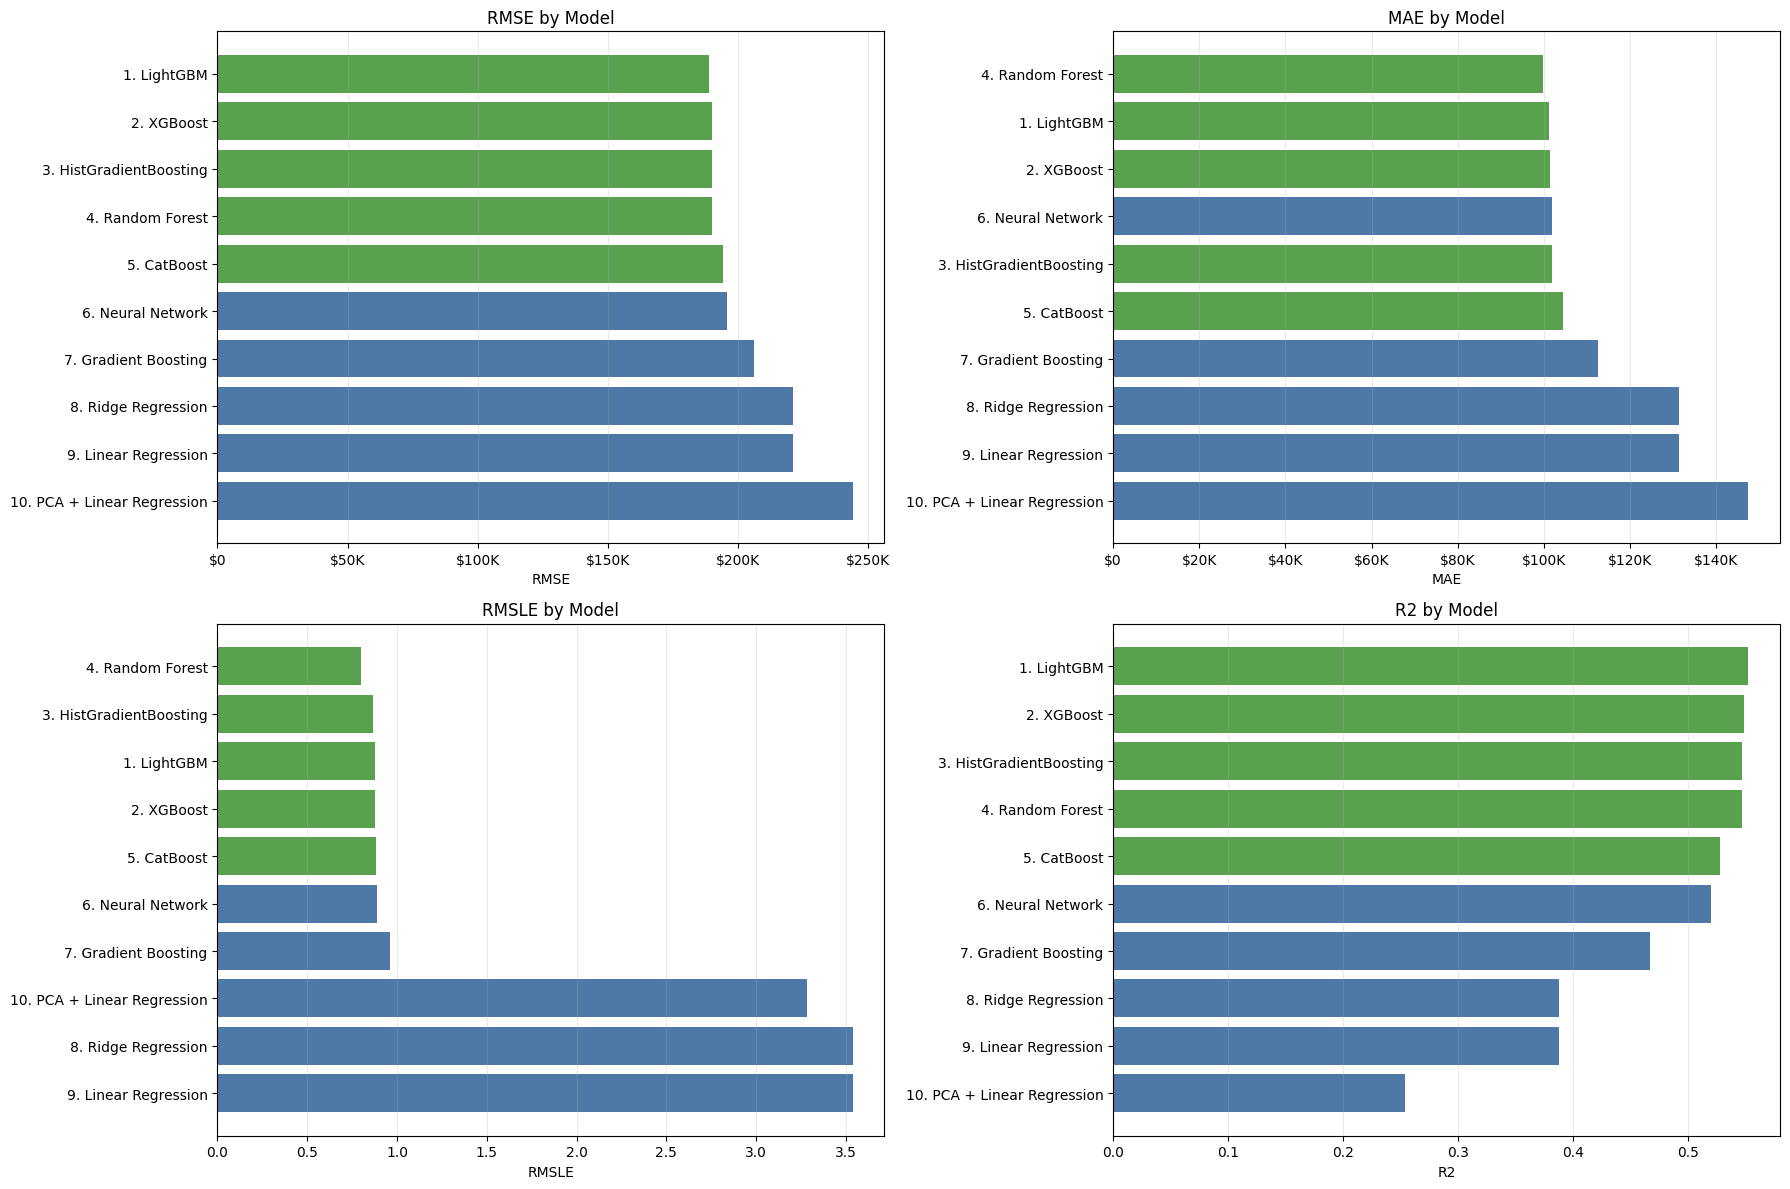

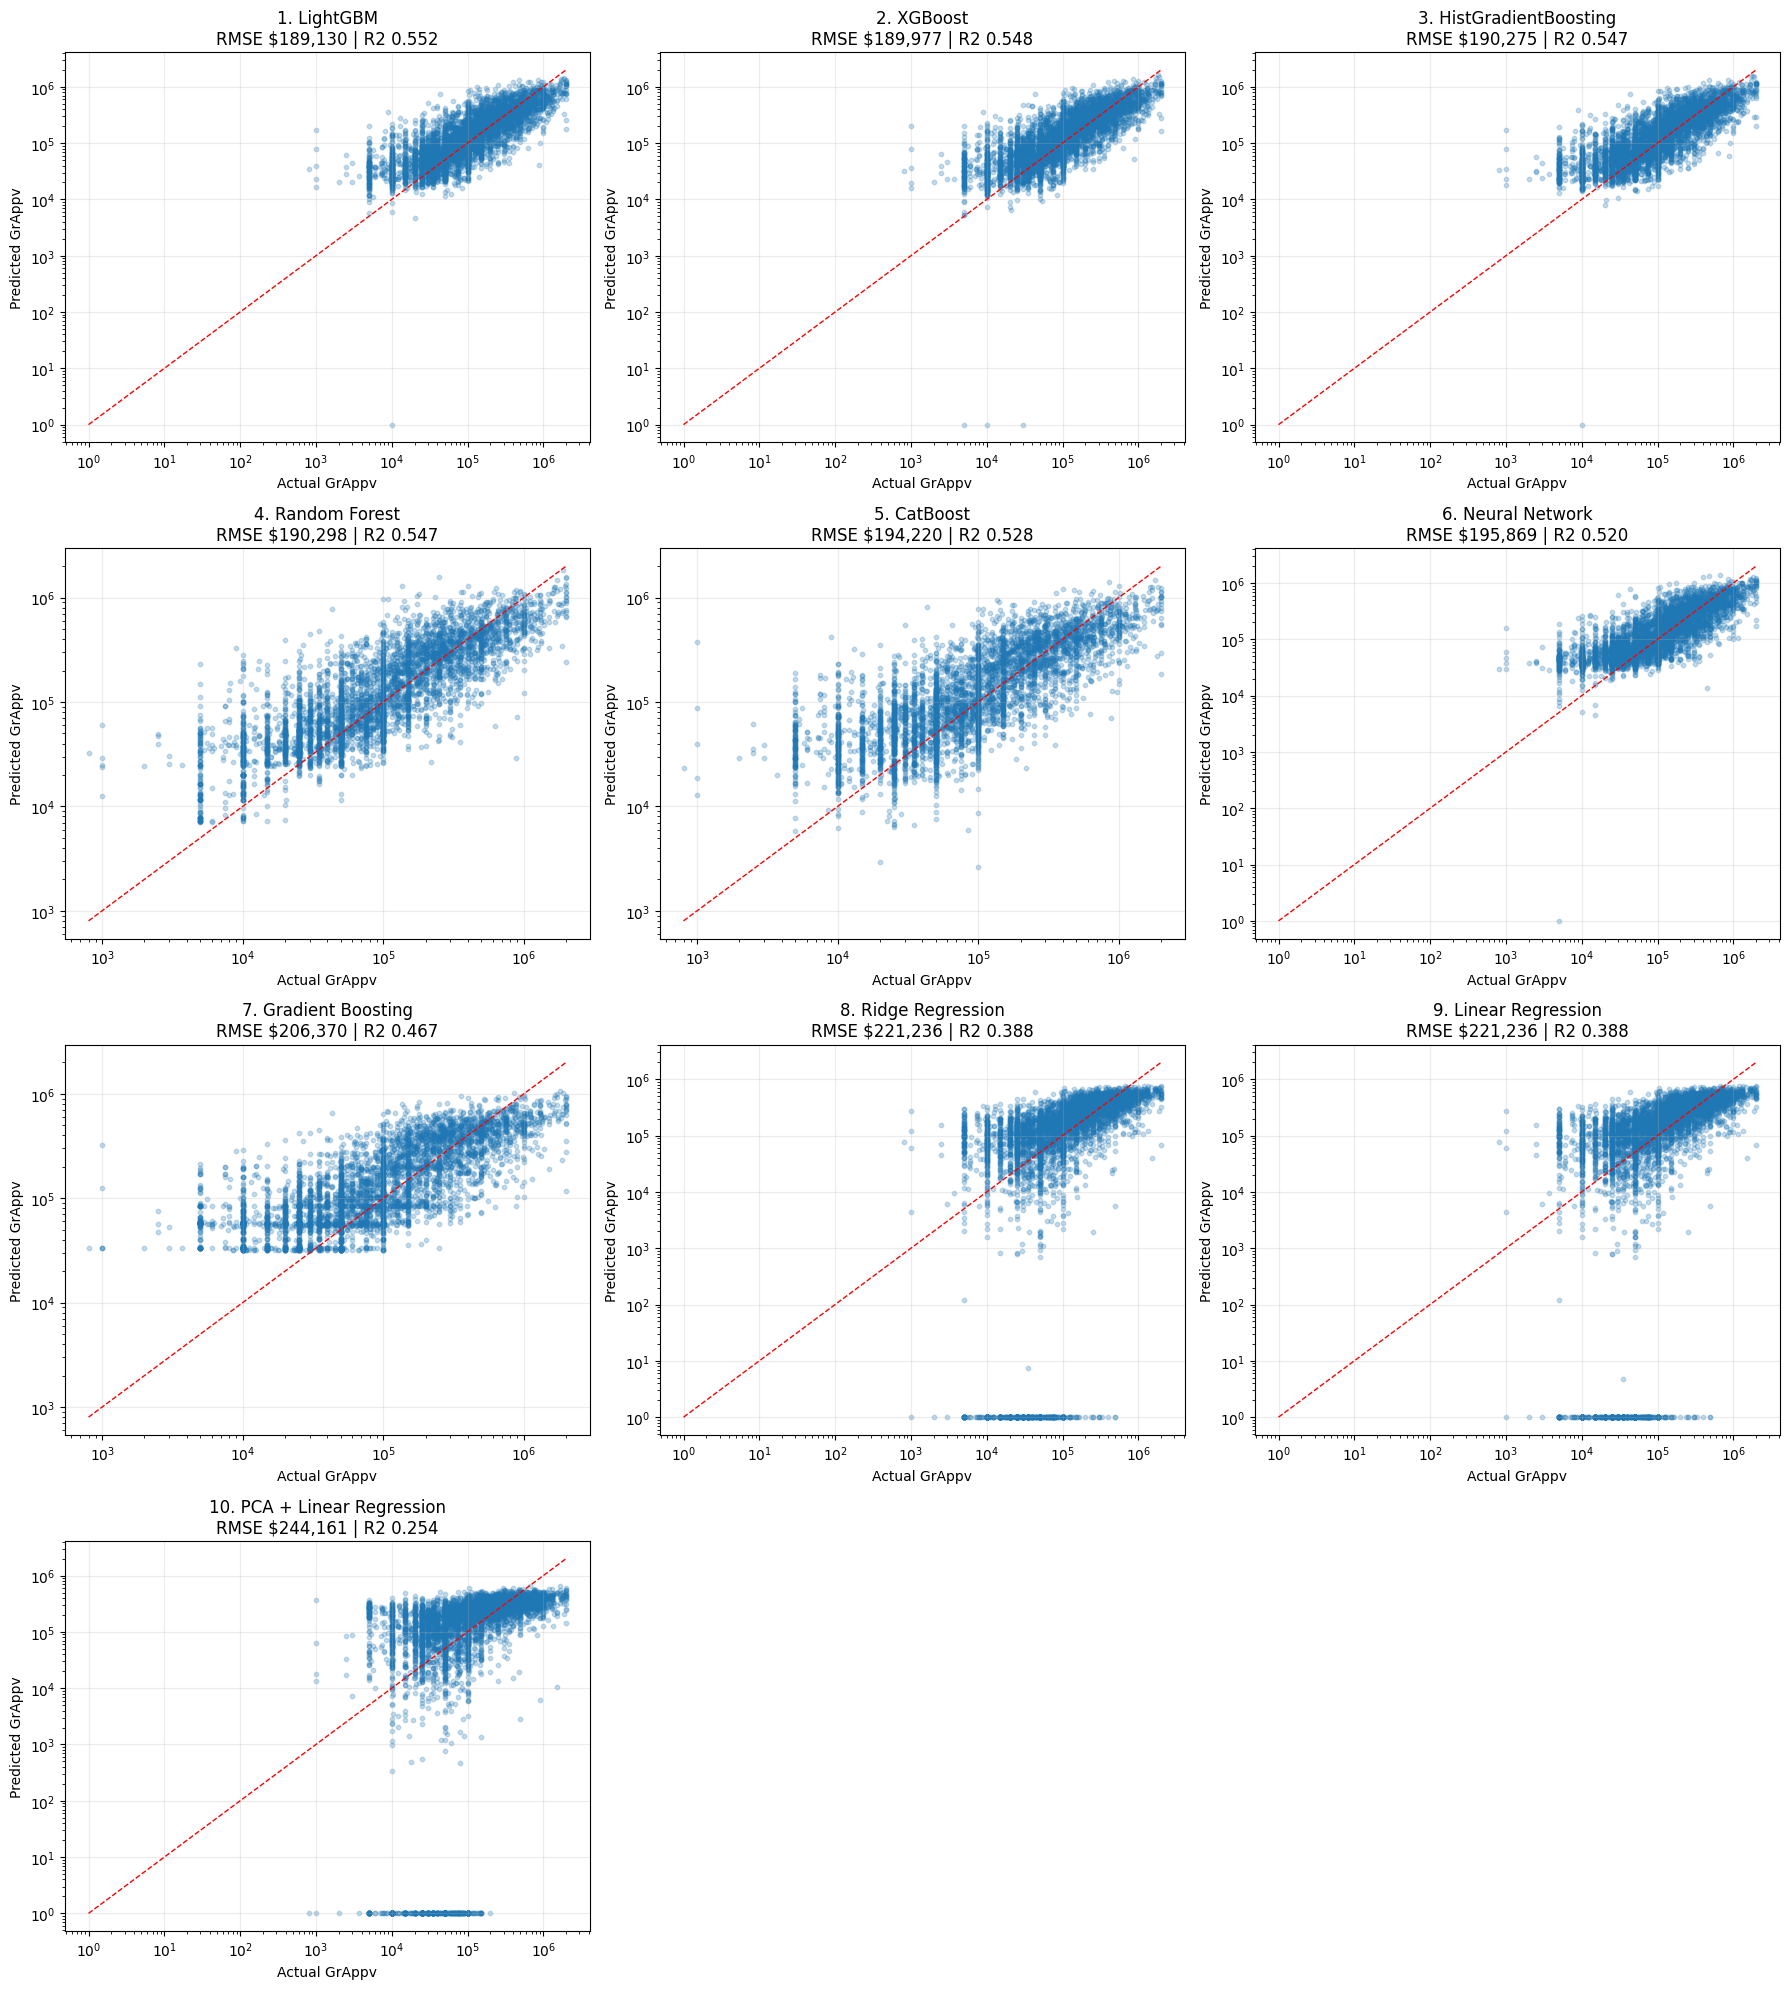

In [63]:
def dollar_formatter(value, _):
    if abs(value) >= 1_000_000:
        return f"${value / 1_000_000:.1f}M"
    if abs(value) >= 1_000:
        return f"${value / 1_000:.0f}K"
    return f"${value:.0f}"


def model_label(row):
    return f"{int(row['Rank'])}. {row['Model']}"


plot_results_df = results_df.copy()
plot_results_df["Model Label"] = plot_results_df.apply(model_label, axis=1)

metric_specs = [
    ("RMSE", "RMSE by Model", True),
    ("MAE", "MAE by Model", True),
    ("RMSLE", "RMSLE by Model", False),
    ("R2", "R2 by Model", False),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

for ax, (metric, title, is_money) in zip(axes, metric_specs):
    ascending = metric != "R2"
    metric_df = plot_results_df.sort_values(metric, ascending=ascending)
    colors = ["#59A14F" if label in top5_results_df.apply(model_label, axis=1).values else "#4E79A7" for label in metric_df["Model Label"]]
    ax.barh(metric_df["Model Label"], metric_df[metric], color=colors)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel(metric)
    if is_money:
        ax.xaxis.set_major_formatter(plt.FuncFormatter(dollar_formatter))
    ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

diagnostic_sample_size = min(5_000, len(y_test_actual))
rng = np.random.default_rng(42)
diagnostic_idx = rng.choice(len(y_test_actual), size=diagnostic_sample_size, replace=False)
actual_sample = y_test_actual[diagnostic_idx]
actual_plot = np.clip(actual_sample, 1, None)

available_model_names = [name for name in results_df["Model"] if name in model_predictions]
n_cols = 3
n_rows = int(np.ceil(len(available_model_names) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = np.asarray(axes).ravel()

for ax, model_name in zip(axes, available_model_names):
    rank_row = results_df.loc[results_df["Model"] == model_name].iloc[0]
    pred_sample = model_predictions[model_name][diagnostic_idx]
    pred_plot = np.clip(pred_sample, 1, None)
    min_val = min(actual_plot.min(), pred_plot.min())
    max_val = max(actual_plot.max(), pred_plot.max())

    ax.scatter(actual_plot, pred_plot, s=10, alpha=0.25)
    ax.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=1)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(
        f"{int(rank_row['Rank'])}. {model_name}\n"
        f"RMSE ${rank_row['RMSE']:,.0f} | R2 {rank_row['R2']:.3f}"
    )
    ax.set_xlabel("Actual GrAppv")
    ax.set_ylabel("Predicted GrAppv")
    ax.grid(True, alpha=0.25)

for ax in axes[len(available_model_names):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


### 3.14 Top 5 Model Diagnostics

The grid above shows that the best models still struggle with extreme loan amounts. The plots below focus on the top 5 models so we can compare their prediction spread and residual pattern more clearly.


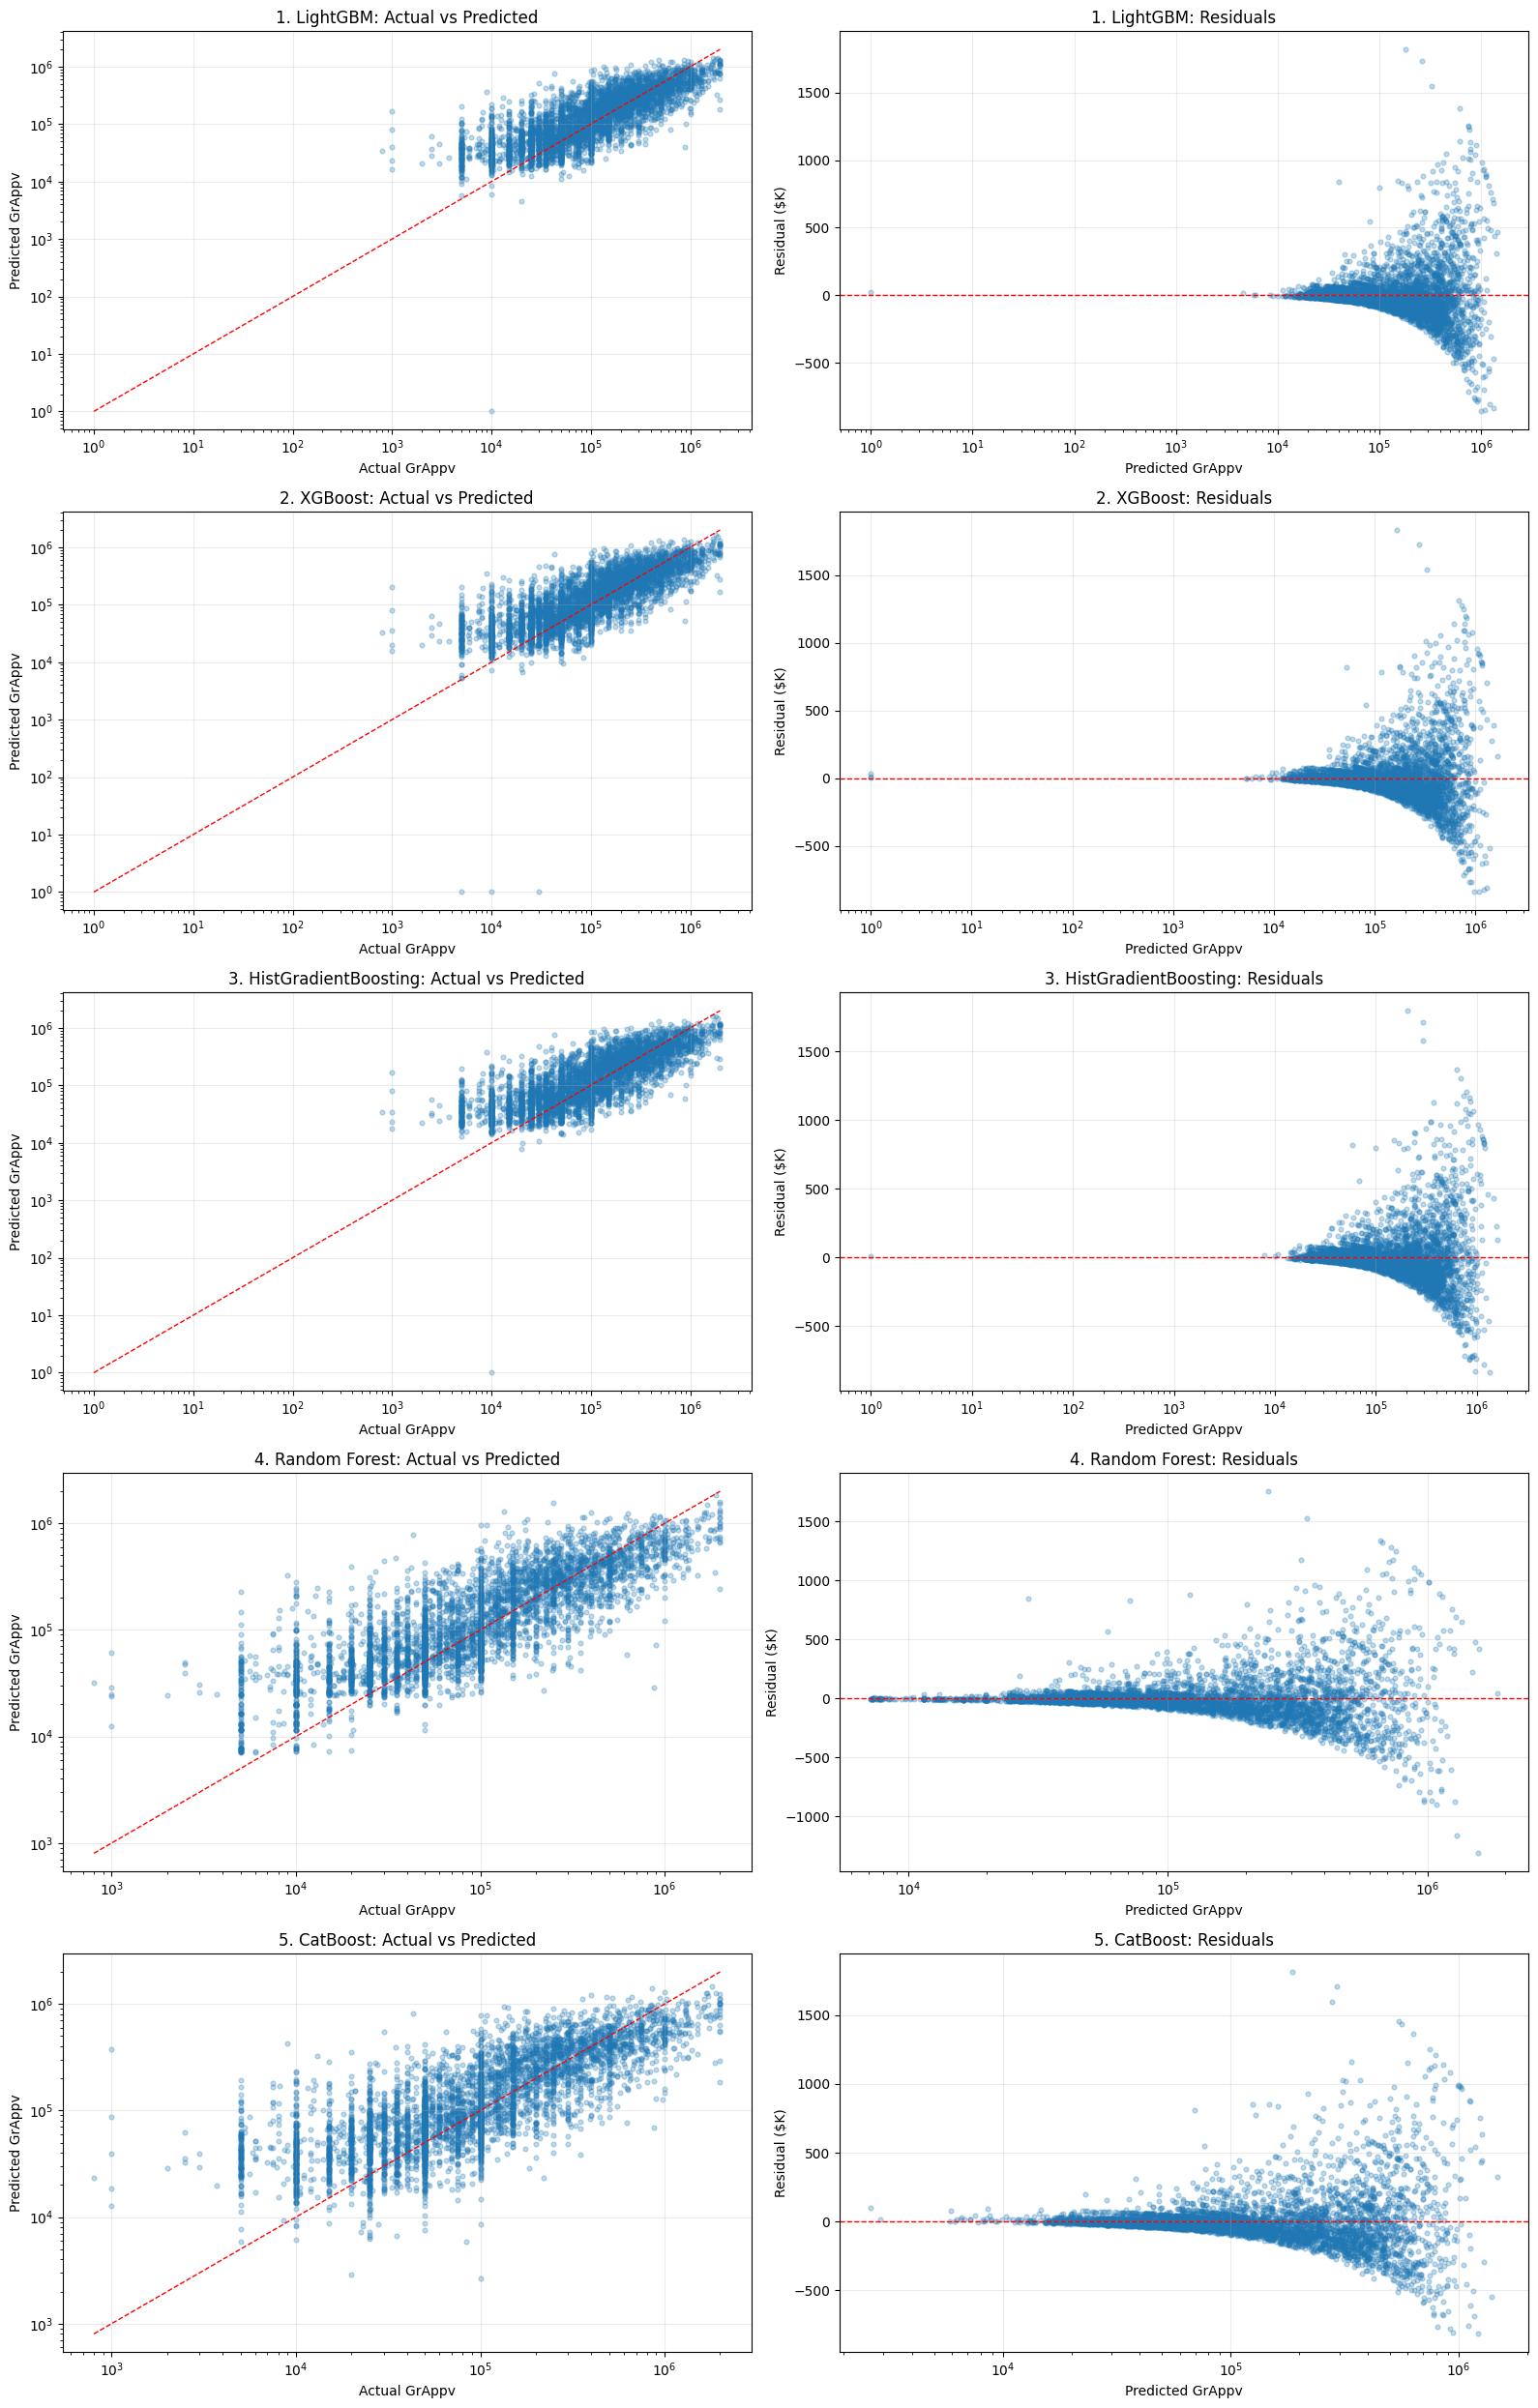

In [64]:
fig, axes = plt.subplots(len(top5_model_names), 2, figsize=(16, 5 * len(top5_model_names)))
if len(top5_model_names) == 1:
    axes = np.asarray([axes])

for row_idx, model_name in enumerate(top5_model_names):
    rank_row = results_df.loc[results_df["Model"] == model_name].iloc[0]
    pred_sample = model_predictions[model_name][diagnostic_idx]
    residual_sample = actual_sample - pred_sample
    pred_plot = np.clip(pred_sample, 1, None)
    min_val = min(actual_plot.min(), pred_plot.min())
    max_val = max(actual_plot.max(), pred_plot.max())

    axes[row_idx, 0].scatter(actual_plot, pred_plot, s=12, alpha=0.28)
    axes[row_idx, 0].plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=1)
    axes[row_idx, 0].set_xscale("log")
    axes[row_idx, 0].set_yscale("log")
    axes[row_idx, 0].set_title(f"{int(rank_row['Rank'])}. {model_name}: Actual vs Predicted")
    axes[row_idx, 0].set_xlabel("Actual GrAppv")
    axes[row_idx, 0].set_ylabel("Predicted GrAppv")
    axes[row_idx, 0].grid(True, alpha=0.25)

    axes[row_idx, 1].scatter(pred_plot, residual_sample / 1000, s=12, alpha=0.28)
    axes[row_idx, 1].axhline(0, color="red", linestyle="--", linewidth=1)
    axes[row_idx, 1].set_xscale("log")
    axes[row_idx, 1].set_title(f"{int(rank_row['Rank'])}. {model_name}: Residuals")
    axes[row_idx, 1].set_xlabel("Predicted GrAppv")
    axes[row_idx, 1].set_ylabel("Residual ($K)")
    axes[row_idx, 1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


### 3.15 What the Diagnostic Plots Show

The LightGBM plot is not perfect, but the issue is not limited to LightGBM. The boosted tree models are close to each other, while the linear and PCA models show weaker fit. The main visual pattern is regression toward the middle: very large loans are often under-predicted and very small loans can be over-predicted. This is why the MAE and RMSE values look large in dollar terms.

RMSE is especially harsh here because it heavily penalizes a small number of large SBA loans. The dataset also does not include some of the strongest real-world approval drivers, such as requested loan amount, business revenue, collateral, credit profile, or lender policy details. So the model is learning from useful but incomplete signals.


### 3.16 Areas to Improve Model Fit

1. Tune the top 5 models using the validation set. Good first parameters to tune are learning rate, number of estimators, max depth, number of leaves, min child samples, subsample, column sample, and L2 regularization.
2. Try a `log1p(GrAppv)` target experiment. This usually improves MAE and RMSLE for skewed money targets, but it may increase RMSE because the model pays less attention to very large loans.
3. Keep richer categorical information. Frequency encoding for `City`, `Zip`, and `Bank` is simple, but it removes identity information. A top-N one-hot encoding or a raw-categorical CatBoost model may improve fit.
4. Add stronger SBA-specific features such as term bands, long-term loan flag, approval decade, ZIP prefix, state-industry interactions, and inflation-adjusted approved amounts.
5. Evaluate errors by loan-size bands, state, industry sector, and term range. If large loans drive most of the RMSE, a separate high-loan model or weighted objective may be better.
6. Avoid leakage columns like `SBA_Appv`, `DisbursementGross`, `MIS_Status`, `ChgOffPrinGr`, and charge-off dates unless the business problem is explicitly post-approval analysis.


### 3.17 Feature Importance

For tree-based models, feature importance shows which processed features were used most often. For linear models, coefficient size gives a rough importance signal.


In [65]:
def get_feature_importance(model_name):
    model = fitted_models.get(model_name)

    if model is None:
        return None

    if hasattr(model, "feature_importances_"):
        importance = model.feature_importances_
    elif hasattr(model, "coef_"):
        importance = np.abs(np.asarray(model.coef_).ravel())
    else:
        return None

    if len(importance) != len(X.columns):
        return None

    return (
        pd.DataFrame({"Feature": X.columns, "Importance": importance})
        .sort_values(by="Importance", ascending=False)
        .head(20)
    )

importance_df = get_feature_importance(best_model_name)

if importance_df is None:
    for candidate in ["LightGBM", "XGBoost", "CatBoost", "Random Forest", "Gradient Boosting", "Ridge Regression"]:
        importance_df = get_feature_importance(candidate)
        if importance_df is not None:
            print(f"Showing feature importance for {candidate}.")
            break

importance_df


,Feature,Importance
0,Term,1202
1,NoEmp,851
9,Bank_freq,785
4,ApprovalFY,769
5,approval_year,547
2,CreateJob,544
3,RetainedJob,489
8,Zip_freq,327
7,City_freq,203
152,NAICS_sector_72,166


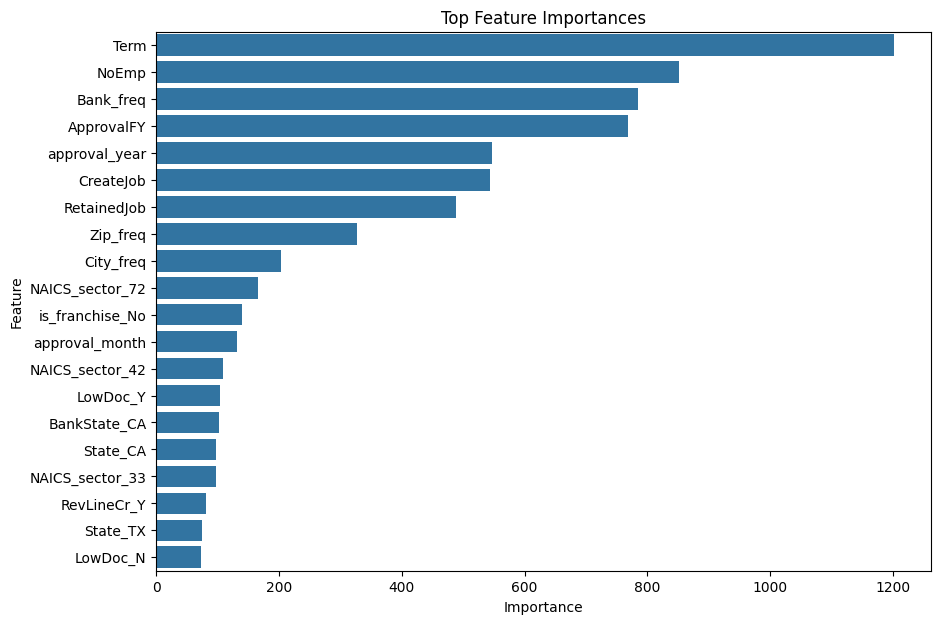

In [66]:
if importance_df is not None:
    plt.figure(figsize=(10, 7))
    sns.barplot(data=importance_df, x="Importance", y="Feature")
    plt.title("Top Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()


### 3.18 Final Notes

The strongest model should be selected from the comparison table, not from assumptions. For this SBA regression task, tree-based boosting models are expected to do well because they can learn non-linear patterns across term, geography, industry, and program flags.
